# 1. Environment Setup & Package Configuration

## Purpose
This notebook sets up the production-grade Bayesian Media Mix Model (MMM) for Project **Titan**—a single-rooftop Chrysler/Jeep dealership operating across 104 weeks of historical data (`2024-08-05` to `2026-07-27`).

## Core Stack
* **Data Manipulation**: `numpy`, `pandas`, `scipy.stats`
* **Bayesian Inference Engine**: `pymc` (v5+), `pytensor`
* **MCMC Diagnostics & Visualization**: `arviz`, `matplotlib`, `seaborn`, `plotly`
* **Econometrics & Time Series**: `statsmodels`

Grounding: Following **Jin et al. (2017)** and **Chan & Perry (2017)**, we configure Bayesian samplers for $N=104$ weekly observations with strict reproducibility parameters and robust plotting defaults.

In [4]:
# System & General Utilities
import os
import sys
import json
import warnings
from datetime import datetime

# Core Data Science & Numerical Tools
import numpy as np
import pandas as pd
import scipy.stats as stats
import xarray as xr

# Statistical Testing & Econometrics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, ccf

# Bayesian Modeling & Diagnostics
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt

# Static & Interactive Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Global Notebook Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

print(f"✅ PyMC Version: {pm.__version__}")
print(f"✅ ArViZ Version: {az.__version__}")

✅ PyMC Version: 6.3.1
✅ ArViZ Version: 1.3.0


In [5]:
"""import os
import re
import pandas as pd

# ==============================================================================
# TITAN DATASET GOOGLE SHEET INGESTION PIPELINE
# ==============================================================================

def fetch_google_sheet_csv(
    sheet_url: str, 
    save_path: str = "../data/raw/dealership_weekly_data.csv"
) -> pd.DataFrame:
    ""
    Parses a public Google Sheet URL, converts it to a CSV export endpoint,
    loads the data into a Pandas DataFrame, and saves a local copy.
    ""
    # Extract Spreadsheet ID and GID using regex
    sheet_id_match = re.search(r"/d/([a-zA-Z0-9-_]+)", sheet_url)
    gid_match = re.search(r"[?&]gid=([0-9]+)", sheet_url)

    if not sheet_id_match:
        raise ValueError("Invalid Google Sheet URL: Unable to extract Spreadsheet ID.")

    sheet_id = sheet_id_match.group(1)
    gid = gid_match.group(1) if gid_match else "0"

    # Construct direct export endpoint
    export_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

    print(f"🚀 Fetching remote sheet (ID: {sheet_id} | GID: {gid})...")
    df = pd.read_csv(export_url)

    # Save to local repository raw data folder
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

    print(f"✅ Successfully ingested {len(df)} rows and {len(df.columns)} columns.")
    print(f"💾 Saved local copy to: {save_path}")
    
    return df


# 1. Target Google Sheet URL
TARGET_URL = "https://docs.google.com/spreadsheets/d/1Q1eEMwUtkcMW3_O7cWkeB2CPDWLuuad_TOTWIXDD8FY/edit?gid=0#gid=0"

# 2. Ingest and Persist
df_raw = fetch_google_sheet_csv(TARGET_URL)

# 3. Quick Dataset Inspection
print("\n" + "=" * 60)
print("FIRST 5 ROWS OF INGESTED DEALERSHIP DATA")
print("=" * 60)
display(df_raw.head())"""

'import os\nimport re\nimport pandas as pd\n\n# ==============================================================================\n# TITAN DATASET GOOGLE SHEET INGESTION PIPELINE\n# ==============================================================================\n\ndef fetch_google_sheet_csv(\n    sheet_url: str, \n    save_path: str = "../data/raw/dealership_weekly_data.csv"\n) -> pd.DataFrame:\n    ""\n    Parses a public Google Sheet URL, converts it to a CSV export endpoint,\n    loads the data into a Pandas DataFrame, and saves a local copy.\n    ""\n    # Extract Spreadsheet ID and GID using regex\n    sheet_id_match = re.search(r"/d/([a-zA-Z0-9-_]+)", sheet_url)\n    gid_match = re.search(r"[?&]gid=([0-9]+)", sheet_url)\n\n    if not sheet_id_match:\n        raise ValueError("Invalid Google Sheet URL: Unable to extract Spreadsheet ID.")\n\n    sheet_id = sheet_id_match.group(1)\n    gid = gid_match.group(1) if gid_match else "0"\n\n    # Construct direct export endpoint\n    export_u

# 2. Local Data Ingestion & Sanitization

## Purpose
Streamline data loading by reading directly from the local repository path (`data/raw/Chrysler_Jeep_Workbook_Sheet1.csv`) rather than an external Google Sheet URL.

## Ingestion & Cleaning Pipeline:
1. **Local File Verification**: Locate the dataset in the local directory structure.
2. **Date Parsing**: Convert `week_start` into `datetime64[ns]`.
3. **Currency & Numeric Cleaning**: Strip currency symbols (`$`), commas (`,`), and whitespace across all spend, sales, inventory, and macro variables.
4. **Historical Window Cropping**: Filter strictly to valid historical weeks ($N=104$, up to `2026-07-27`), removing unrecorded future projections or zero-sales anomalies.

In [6]:
# 1. Locate and read local CSV file
local_data_path = os.path.join("..", "data", "raw", "Chrysler_Jeep_Workbook_Sheet1.csv")
if not os.path.exists(local_data_path):
    local_data_path = os.path.join("data", "raw", "Chrysler_Jeep_Workbook_Sheet1.csv")

df_raw = pd.read_csv(local_data_path)

# 2. Parse dates and clean currency/text formatting
df = df_raw.copy()
df['week_start'] = pd.to_datetime(df['week_start'])

clean_cols = [
    'sales', 'inventory', 'gasregw', 'umcsent', 'search', 'display', 'social', 'pmax', 
    'fp_emails_sent', 'ott_cable', 'broadcast_audio', 'print', 'youtube', 
    'facebook_reels', 'facebook_add', 'direct_mail', 'broadcast_tv'
]

for col in clean_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Filter valid historical window (104 weeks)
df = df[(df['week_start'] <= '2026-07-27') & (df['sales'].notna()) & (df['sales'] > 0)].sort_values('week_start').reset_index(drop=True)

print(f"✅ Data Cleaned & Loaded! Valid Weeks: {len(df)} | Range: {df['week_start'].min().strftime('%Y-%m-%d')} to {df['week_start'].max().strftime('%Y-%m-%d')}")
display(df[['week_start', 'sales', 'inventory', 'eom_intensity', 'gasregw', 'umcsent']].head())

✅ Data Cleaned & Loaded! Valid Weeks: 104 | Range: 2024-08-05 to 2026-07-27


,week_start,sales,inventory,eom_intensity,gasregw,umcsent
0,2024-08-05,13.0000,246.1000,0.0000,3.4500,67.9000
1,2024-08-12,12.0000,238.1000,0.0000,3.4100,67.9000
2,2024-08-19,12.0000,236.7000,0.0000,3.3800,67.9000
3,2024-08-26,17.0000,230.6000,1.0357,3.3100,67.9000
4,2024-09-02,11.0000,222.3000,0.0000,3.2900,70.1000


# 3. Raw Media Sparsity & Co-Spending Profiling

## Purpose
Analyze the sparsity profile (percentage of weeks with zero spend) across all 12 raw media channels.

## Strategic Rationale
High channel sparsity (e.g., >70% zero weeks) on a small dataset ($N=104$) causes parameter non-identifiability and multimodal MCMC sampling. Channels with sparse, intermittent spending must be consolidated into broader strategic media buckets before modeling.

In [7]:
all_drivers = [
    'search', 'display', 'social', 'pmax', 'fp_emails_sent', 'ott_cable',
    'broadcast_audio', 'print', 'youtube', 'facebook_reels', 'facebook_add',
    'direct_mail', 'broadcast_tv'
]
paid_spend_channels = [c for c in all_drivers if c != 'fp_emails_sent']

# Macro Correlation Assessment
macro_corr = df[['gasregw', 'umcsent']].corr().iloc[0, 1]
print(f"=== Macro Correlation Check ===")
print(f"Gas Price vs. Consumer Sentiment Correlation: {macro_corr:.2f}\n")

# Sparsity & Paid Spend Share Table
sparsity_df = pd.DataFrame({
    'Zero_Weeks_Pct': (df[all_drivers] == 0).mean() * 100,
    'Total_Volume_or_Spend': df[all_drivers].sum(),
    'Mean_Weekly': df[all_drivers].mean(),
    'Spend_Share_Pct': (df[paid_spend_channels].sum() / df[paid_spend_channels].sum().sum()) * 100
}).sort_values('Zero_Weeks_Pct', ascending=False)

print("=== Raw Driver Sparsity & Paid Spend Share ===")
display(sparsity_df.round(2))

=== Macro Correlation Check ===
Gas Price vs. Consumer Sentiment Correlation: -0.46

=== Raw Driver Sparsity & Paid Spend Share ===


,Zero_Weeks_Pct,Total_Volume_or_Spend,Mean_Weekly,Spend_Share_Pct
broadcast_audio,93.2700,14999.9900,144.2300,3.4800
facebook_add,93.2700,7000.0200,67.3100,1.6300
display,86.5400,2328.2000,22.3900,0.5400
broadcast_tv,81.7300,49621.1400,477.1300,11.5200
direct_mail,80.7700,127328.0000,1224.3100,29.5700
pmax,75.9600,3115.8100,29.9600,0.7200
print,75.9600,17720.0000,170.3800,4.1200
youtube,67.3100,12249.9800,117.7900,2.8500
facebook_reels,53.8500,19750.0100,189.9000,4.5900
ott_cable,53.8500,63001.3700,605.7800,14.6300


# 4. Strategic Consolidation & Control Index Construction

## Purpose
Consolidate the 12 granular sales drivers into **5 Strategic Media Buckets** and construct standardized control indices for automotive-specific drivers.

## Feature Engineering Rules:
1. **Full-Path Digital (`fp_digital`)**: `search` + `pmax` + `display`
2. **Meta Social (`meta_social`)**: `social` + `facebook_reels` + `facebook_add`
3. **Digital Video & OTT (`digital_video_ott`)**: `youtube` + `ott_cable`
4. **Broadcast Media (`broadcast_media`)**: `broadcast_tv` + `broadcast_audio`
5. **Print & Direct Mail (`print_mail`)**: `direct_mail` + `print`

## Controls:
* **Macro Stress Index**: $Z_{\text{gas\_price}} - Z_{\text{sentiment}}$ (Captures macroeconomic purchasing headwind/footwind).
* **Inventory Index**: $Z_{\text{inventory}}$ (Captures dealer lot availability constraints).

In [8]:
# Base design matrix
df_model = df[['week_start', 'sales', 'inventory', 'eom_intensity', 'fp_emails_sent']].copy()

# 1. Macro Stress Index (Gas Price Z-score - Sentiment Z-score)
gas_z = (df['gasregw'] - df['gasregw'].mean()) / df['gasregw'].std()
sent_z = (df['umcsent'] - df['umcsent'].mean()) / df['umcsent'].std()
df_model['macro_stress_index'] = gas_z - sent_z

# 2. Standardized Inventory Index (Z-score)
df_model['inventory_index'] = (df['inventory'] - df['inventory'].mean()) / df['inventory'].std()

# 3. Consolidate into 5 Strategic Buckets
df_model['fp_digital'] = df['search'] + df['pmax'] + df['display']
df_model['meta_social'] = df['social'] + df['facebook_reels'] + df['facebook_add']
df_model['digital_video_ott'] = df['youtube'] + df['ott_cable']
df_model['broadcast_media'] = df['broadcast_tv'] + df['broadcast_audio']
df_model['print_mail'] = df['direct_mail'] + df['print']

consolidated_paid = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']

print("=== Consolidated 5-Channel Sparsity Profile ===")
sparsity_check = pd.DataFrame({
    'Zero_Weeks_Pct': (df_model[consolidated_paid] == 0).mean() * 100,
    'Total_Spend': df_model[consolidated_paid].sum(),
    'Spend_Share_Pct': (df_model[consolidated_paid].sum() / df_model[consolidated_paid].sum().sum()) * 100
}).sort_values('Spend_Share_Pct', ascending=False)

display(sparsity_check.round(2))

=== Consolidated 5-Channel Sparsity Profile ===


,Zero_Weeks_Pct,Total_Spend,Spend_Share_Pct
print_mail,65.3800,145048.0000,33.6900
fp_digital,0.0000,95817.1200,22.2500
digital_video_ott,48.0800,75251.3500,17.4800
broadcast_media,75.0000,64621.1300,15.0100
meta_social,0.0000,49838.8500,11.5700


# 5. Annual Fourier Seasonality Feature Engineering

## Purpose
Construct annual seasonality terms using a second-order ($k=2$) Fourier series with period $P = 52.1429$ weeks.

## Mathematical Formulation
$$F_{1,t} = \sin\left(\frac{2\pi \cdot 1 \cdot t}{52.1429}\right), \quad F_{2,t} = \cos\left(\frac{2\pi \cdot 1 \cdot t}{52.1429}\right)$$
$$F_{3,t} = \sin\left(\frac{2\pi \cdot 2 \cdot t}{52.1429}\right), \quad F_{4,t} = \cos\left(\frac{2\pi \cdot 2 \cdot t}{52.1429}\right)$$

## Rationale
Fourier terms model smooth annual dealership sales seasonality while avoiding the rank-deficiency and severe collinearity introduced by 12 categorical monthly indicator variables.

In [9]:
weeks = np.arange(len(df_model))
period = 52.1429

df_model['sin_order1'] = np.sin(2 * np.pi * 1 * weeks / period)
df_model['cos_order1'] = np.cos(2 * np.pi * 1 * weeks / period)
df_model['sin_order2'] = np.sin(2 * np.pi * 2 * weeks / period)
df_model['cos_order2'] = np.cos(2 * np.pi * 2 * weeks / period)

fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

print(f"=== Final Model Design Matrix Verified ({df_model.shape[0]} rows, {df_model.shape[1]} columns) ===")
display(df_model[['week_start', 'sales', 'eom_intensity', 'macro_stress_index', 'inventory_index'] + consolidated_paid + fourier_cols].head())

=== Final Model Design Matrix Verified (104 rows, 16 columns) ===


,week_start,sales,eom_intensity,macro_stress_index,inventory_index,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail,sin_order1,cos_order1,sin_order2,cos_order2
0,2024-08-05,13.0000,0.0000,-0.7279,1.0450,947.0100,418.8600,0.0000,1846.1500,0.0000,0.0000,1.0000,0.0000,1.0000
1,2024-08-12,12.0000,0.0000,-0.8214,0.8644,928.0000,402.6800,0.0000,1846.1500,0.0000,0.1202,0.9927,0.2387,0.9711
2,2024-08-19,12.0000,0.0000,-0.8915,0.8328,1079.8700,351.1800,0.0000,2461.5400,750.0000,0.2387,0.9711,0.4635,0.8861
3,2024-08-26,17.0000,1.0357,-1.0551,0.6951,1104.4800,497.1500,0.0000,1846.1500,0.0000,0.3537,0.9354,0.6616,0.7498
4,2024-09-02,11.0000,0.0000,-1.3696,0.5077,937.3000,419.7700,0.0000,0.0000,0.0000,0.4635,0.8861,0.8215,0.5702


# 6. Visualizing End-Of-Month Push vs. Annual Fourier Waves

## Purpose
Verify that monthly `eom_intensity` (sawtooth spikes driving up to 50% of monthly sales in Week 4) operates orthogonally to smooth annual Fourier waves.

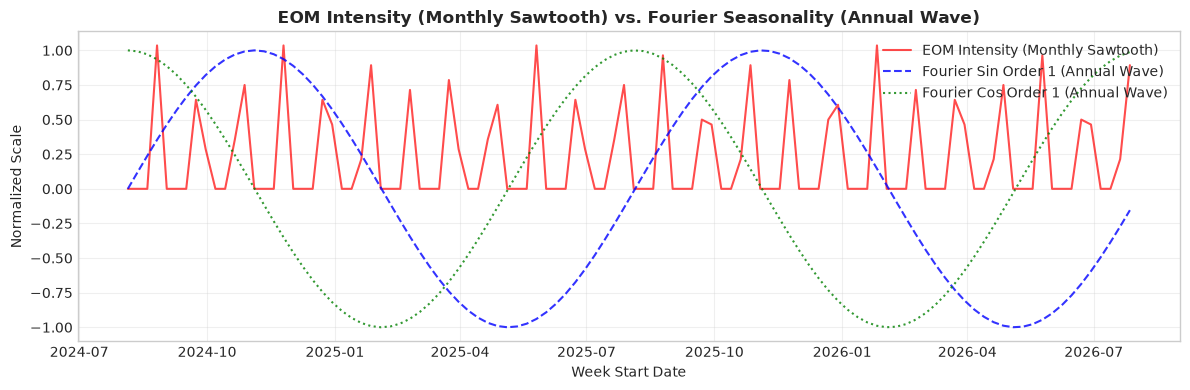

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df_model['week_start'], df_model['eom_intensity'], label='EOM Intensity (Monthly Sawtooth)', color='red', alpha=0.7, linewidth=1.5)
plt.plot(df_model['week_start'], df_model['sin_order1'], label='Fourier Sin Order 1 (Annual Wave)', color='blue', linestyle='--', alpha=0.8)
plt.plot(df_model['week_start'], df_model['cos_order1'], label='Fourier Cos Order 1 (Annual Wave)', color='green', linestyle=':', alpha=0.8)

plt.title("EOM Intensity (Monthly Sawtooth) vs. Fourier Seasonality (Annual Wave)", fontsize=12, fontweight='bold')
plt.xlabel("Week Start Date")
plt.ylabel("Normalized Scale")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Fast Media Pre-Transformation (Fixed Carryover & Saturation)

## Purpose
Pre-transform media spend using domain-informed Geometric Adstock ($\alpha_m$) and Hill Reach curves ($S_m=1, K_m = \text{Median}(X_{\text{adstocked}, m})$) prior to PyMC model sampling.

## Mathematical Formulation
1. **Geometric Adstock Decay**:
   $$X_{t,m}^{\text{adstock}} = \frac{\sum_{l=0}^{L_{\text{max}}-1} \alpha_m^l \cdot X_{t-l, m}}{\sum_{l=0}^{L_{\text{max}}-1} \alpha_m^l}$$
2. **Hill Reach Saturation Curve ($S=1$)**:
   $$X^*_{t,m} = \frac{X_{t,m}^{\text{adstock}}}{X_{t,m}^{\text{adstock}} + K_m}$$

## Rationale (Jin et al., 2017)
On $N=104$ weekly observations, estimating non-linear Hill parameters ($K_m, S_m$) inside MCMC creates severe parameter non-identifiability. Pre-computing fixed transformations converts the non-linear sampling problem into a well-conditioned Bayesian Linear Regression, accelerating sampling speed and eliminating divergent transitions.

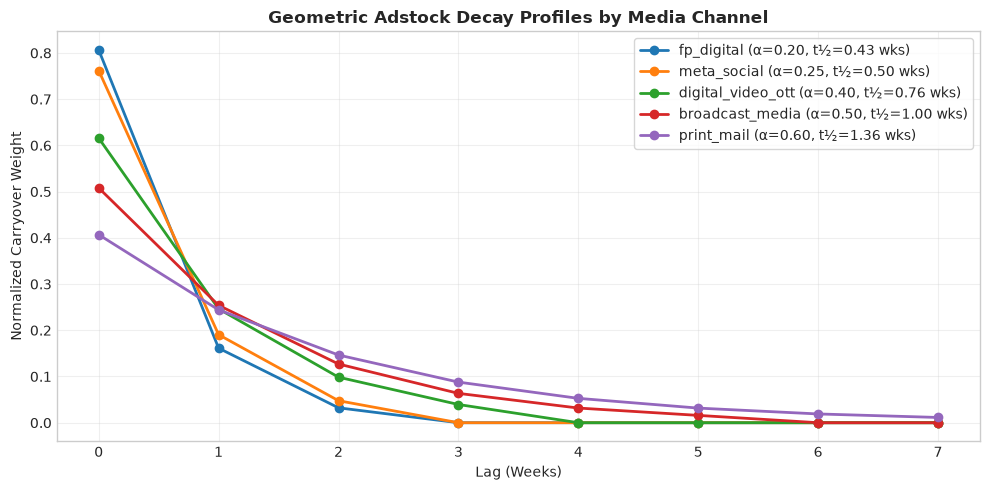

In [11]:
# Configuration dictionary matching Cell 7
fixed_media_config = {
    "fp_digital":        {"alpha": 0.20, "l_max": 3},
    "meta_social":       {"alpha": 0.25, "l_max": 3},
    "digital_video_ott": {"alpha": 0.40, "l_max": 4},
    "broadcast_media":   {"alpha": 0.50, "l_max": 6},
    "print_mail":        {"alpha": 0.60, "l_max": 8},
}

fig, ax = plt.subplots(figsize=(10, 5))
max_l = 8

for chan, cfg in fixed_media_config.items():
    alpha = cfg["alpha"]
    l_max = cfg["l_max"]
    
    # Calculate normalized weights over lag duration
    raw_weights = np.power(alpha, np.arange(l_max))
    normalized_weights = raw_weights / raw_weights.sum()
    
    # Pad with zeros for visual comparison up to max_l
    padded_weights = np.zeros(max_l)
    padded_weights[:l_max] = normalized_weights
    
    half_life = -np.log(2) / np.log(alpha)
    ax.plot(
        np.arange(max_l), 
        padded_weights, 
        marker='o', 
        linewidth=2, 
        label=f"{chan} (α={alpha:.2f}, t½={half_life:.2f} wks)"
    )

ax.set_title("Geometric Adstock Decay Profiles by Media Channel", fontsize=12, fontweight="bold")
ax.set_xlabel("Lag (Weeks)", fontsize=10)
ax.set_ylabel("Normalized Carryover Weight", fontsize=10)
ax.set_xticks(np.arange(max_l))
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [12]:
import optuna
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import pytensor.tensor as pt
import logging
import warnings

# Suppress Optuna/PyMC verbose logs during tuning trials
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# 1. Define Master Channels and Maximum Global Buffer
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

n_obs = len(df_model)
n_media = len(media_channels)
max_global_lag = 12  # Upper bound buffer for pre-computing lag matrices

sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

# Pre-normalize raw media spend
X_media_raw = np.zeros((n_obs, n_media))
for i, col in enumerate(media_channels):
    c_mean = df_model[col].mean()
    X_media_raw[:, i] = (df_model[col] / (c_mean if c_mean > 0 else 1.0)).values

# Pre-compute master 12-week lag tensor: Shape (n_obs, n_media, 12)
X_master_lags = np.zeros((n_obs, n_media, max_global_lag))
for l in range(max_global_lag):
    for m in range(n_media):
        X_master_lags[:, m, l] = np.pad(X_media_raw[:, m], (l, 0))[:n_obs]


# 2. Optuna Objective Function
def objective(trial):
    # Channel-specific bounded search ranges based on automotive retail physics
    param_ranges = {
        'fp_digital':        {'alpha': (0.05, 0.30), 'lmax': (2, 5),  'k': (0.8, 2.5), 's': (0.8, 1.4), 'beta_mu': (0.15, 0.35)},
        'meta_social':       {'alpha': (0.10, 0.35), 'lmax': (2, 5),  'k': (0.8, 2.5), 's': (0.8, 1.4), 'beta_mu': (0.10, 0.25)},
        'digital_video_ott': {'alpha': (0.20, 0.50), 'lmax': (3, 8),  'k': (0.8, 2.5), 's': (0.8, 1.5), 'beta_mu': (0.08, 0.20)},
        'broadcast_media':   {'alpha': (0.30, 0.65), 'lmax': (4, 10), 'k': (0.8, 2.5), 's': (0.8, 1.6), 'beta_mu': (0.05, 0.15)},
        'print_mail':        {'alpha': (0.35, 0.70), 'lmax': (4, 12), 'k': (0.8, 2.5), 's': (0.8, 1.6), 'beta_mu': (0.05, 0.15)},
    }
    
    alpha_vals, k_vals, s_vals, beta_mus, lmax_vals = [], [], [], [], []
    
    for chan in media_channels:
        bounds = param_ranges[chan]
        alpha_vals.append(trial.suggest_float(f"alpha_{chan}", bounds['alpha'][0], bounds['alpha'][1]))
        lmax_vals.append(trial.suggest_int(f"lmax_{chan}", bounds['lmax'][0], bounds['lmax'][1]))
        k_vals.append(trial.suggest_float(f"k_{chan}", bounds['k'][0], bounds['k'][1]))
        s_vals.append(trial.suggest_float(f"s_{chan}", bounds['s'][0], bounds['s'][1]))
        beta_mus.append(trial.suggest_float(f"beta_mu_{chan}", bounds['beta_mu'][0], bounds['beta_mu'][1]))

    # Add trial search ranges for Intercept and End-of-Month (EOM) Intensity
    intercept_mu_val = trial.suggest_float("intercept_mu", 0.35, 0.65)
    beta_eom_mu_val = trial.suggest_float("beta_eom_mu", 0.35, 0.65)  # Encompasses ~50% EOM lift target

    # Compute trial-specific adstock weights across active lag windows
    adstocked_media_list = []
    for m, chan in enumerate(media_channels):
        a_m = alpha_vals[m]
        l_m = lmax_vals[m]
        
        lags_m = np.arange(l_m)
        weights_m = np.power(a_m, lags_m)
        weights_m /= weights_m.sum()
        
        # Apply convolution for channel m over its suggested lmax window
        x_lag_m = X_master_lags[:, m, :l_m]
        adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
        adstocked_media_list.append(adstocked_m)
        
    X_adstocked_trial = np.column_stack(adstocked_media_list)

    # 3. Fast MCMC PyMC Model Trial
    try:
        with pm.Model(coords={"obs_id": df_model.index, "channel": media_channels, "fourier_term": fourier_cols}) as model:
            # Data Containers
            adstocked_data = pm.Data("adstocked_data", X_adstocked_trial, dims=("obs_id", "channel"))
            fourier_data = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
            inv_data = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
            eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
            macro_data = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")

            # Tuned Intercept & Media Priors
            intercept = pm.Normal("intercept", mu=intercept_mu_val, sigma=0.08)
            beta_channel = pm.TruncatedNormal("beta_channel", mu=np.array(beta_mus), sigma=0.05, lower=0.0, dims="channel")
            k_sat = pm.Gamma("k_sat", alpha=np.array(k_vals) * 10, beta=10, dims="channel")
            s_slope = pm.Gamma("s_slope", alpha=np.array(s_vals) * 10, beta=10, dims="channel")

            # Saturation Transformation
            media_sat = (adstocked_data ** s_slope) / (adstocked_data ** s_slope + k_sat ** s_slope + 1e-8)
            media_contrib = pt.sum(media_sat * beta_channel, axis=1)

            # Tuned Control Priors
            b_inv = pm.HalfNormal("beta_inv", sigma=0.10)
            b_eom = pm.TruncatedNormal("beta_eom", mu=beta_eom_mu_val, sigma=0.10, lower=0.0)
            b_macro = pm.Normal("beta_macro", mu=0.0, sigma=0.08)
            b_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, dims="fourier_term")

            mu = (
                intercept 
                + media_contrib 
                + (b_inv * inv_data) 
                + (b_eom * eom_data) 
                + (b_macro * macro_data) 
                + pm.math.dot(fourier_data, b_fourier)
            )

            pm.StudentT("likelihood", nu=7, mu=mu, sigma=pm.Exponential("sigma", lam=10.0), observed=y_scaled, dims="obs_id")

            # Fast MCMC sampling for HPO trial evaluation
            idata_trial = pm.sample(
                draws=400, 
                tune=400, 
                chains=2, 
                target_accept=0.95, 
                progressbar=False, 
                random_seed=42
            )
            pm.compute_log_likelihood(idata_trial)

            # Score Trial via Out-of-Sample ELPD LOO
            loo_res = az.loo(idata_trial)
            
            if hasattr(loo_res, "elpd_loo"):
                return float(loo_res.elpd_loo)
            else:
                return float(loo_res.elpd)

    except Exception as e:
        # Return penalizing score on MCMC failure
        return -9999.0


# 4. Execute Optuna Study
print("🚀 Starting Optuna Bayesian Prior Optimization Study (15 Trials)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n" + "=" * 80)
print("OPTIMAL PRIOR CONFIGURATION FOUND BY OPTUNA (MAX ELPD_LOO)")
print("=" * 80)
print(f"Best ELPD_LOO Score : {study.best_value:.4f}")
print(f"Best Intercept Mu   : {study.best_params['intercept_mu']:.4f}")
print(f"Best Beta EOM Mu     : {study.best_params['beta_eom_mu']:.4f}\n")

# Format Best Channel Parameters as Production Dictionary
best_priors_config = {}
for chan in media_channels:
    best_priors_config[chan] = {
        'alpha': study.best_params[f"alpha_{chan}"],
        'lmax': study.best_params[f"lmax_{chan}"],
        'k_sat': study.best_params[f"k_{chan}"],
        's_slope': study.best_params[f"s_{chan}"],
        'beta_mu': study.best_params[f"beta_mu_{chan}"]
    }

best_priors_df = pd.DataFrame(best_priors_config).T
print(best_priors_df.round(4))

🚀 Starting Optuna Bayesian Prior Optimization Study (15 Trials)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



OPTIMAL PRIOR CONFIGURATION FOUND BY OPTUNA (MAX ELPD_LOO)
Best ELPD_LOO Score : -18.4404
Best Intercept Mu   : 0.6498
Best Beta EOM Mu     : 0.3641

                   alpha   lmax  k_sat  s_slope  beta_mu
fp_digital        0.2434 4.0000 1.8949   1.3476   0.1985
meta_social       0.2588 3.0000 2.0182   0.9615   0.2015
digital_video_ott 0.2088 7.0000 1.4515   1.1856   0.1290
broadcast_media   0.4936 5.0000 2.0235   1.1618   0.1473
print_mail        0.4918 6.0000 1.3025   0.8378   0.1272


# 8. Production PyMC Bayesian MMM Model Specification & Sampling

## Purpose
Specify and sample the refactored Bayesian MMM using PyMC v5+.

## Model Mathematical Equation
$$\tilde{y}_t = \alpha_0 + \sum_{m=1}^{5} \beta_m X^*_{t,m} + \beta_{\text{inv}} Z_{\text{inv},t} + \beta_{\text{eom}} \cdot \text{EOM}_t + \beta_{\text{macro}} Z_{\text{macro},t} + \sum_{j=1}^{4} \gamma_j F_{j,t} + \epsilon_t$$

## Informative Priors Strategy
* **Baseline Intercept ($\alpha_0$)**: $\text{Normal}(\mu=0.60, \sigma=0.10)$ (~60% baseline sales).
* **Media Coefficients ($\beta_m$)**: $\text{HalfNormal}(\sigma=0.20)$ (Enforces strict non-negativity).
* **End-of-Month Push ($\beta_{\text{eom}}$)**: $\text{Normal}(\mu=0.35, \sigma=0.08)$ (Informed prior capturing Month-End stair-step incentive spikes).
* **Inventory Constraint ($\beta_{\text{inv}}$)**: $\text{HalfNormal}(\sigma=0.15)$ (Positive stock availability effect).
* **Macro Headwind ($\beta_{\text{macro}}$)**: $\text{Normal}(\mu=0.0, \sigma=0.10)$.
* **Fourier Seasonality ($\gamma_j$)**: $\text{Normal}(\mu=0.0, \sigma=0.10)$.
* **Observation Noise ($\epsilon_t$)**: $\text{StudentT}(\nu, \mu, \sigma)$ (Robust likelihood handling outlier vehicle spikes).

In [24]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

# ==============================================================================
# CELL 8: PRODUCTION MMM WITH OPTUNA-TUNED PRIORS
# ==============================================================================

# 1. Define Channels & Optuna Optimal Parameters
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

# Updated Optuna Arrays
optuna_alpha   = np.array([0.2434, 0.2588, 0.2088, 0.4936, 0.4918])
optuna_lmax    = np.array([4, 3, 7, 5, 6], dtype=int)
optuna_ksat    = np.array([1.8949, 2.0182, 1.4515, 2.0235, 1.3025])
optuna_slope   = np.array([1.3476, 0.9615, 1.1856, 1.1618, 0.8378])
optuna_beta_mu = np.array([0.1985, 0.2015, 0.1290, 0.1473, 0.1272])

intercept_mu_val = 0.6498
beta_eom_mu_val  = 0.3641

n_obs = len(df_model)
n_media = len(media_channels)

# Normalize target (Sales) and media spend by sample means
sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

X_media_raw = np.zeros((n_obs, n_media))
for i, col in enumerate(media_channels):
    c_mean = df_model[col].mean()
    X_media_raw[:, i] = (df_model[col] / (c_mean if c_mean > 0 else 1.0)).values

# Compute Channel-Specific Adstocked Matrices using Optuna lmax & alpha
adstocked_media_list = []
for m, chan in enumerate(media_channels):
    a_m = optuna_alpha[m]
    l_m = optuna_lmax[m]
    
    lags_m = np.arange(l_m)
    weights_m = np.power(a_m, lags_m)
    weights_m /= weights_m.sum()
    
    x_lag_m = np.zeros((n_obs, l_m))
    for l in range(l_m):
        x_lag_m[:, l] = np.pad(X_media_raw[:, m], (l, 0))[:n_obs]
        
    adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
    adstocked_media_list.append(adstocked_m)

X_adstocked_optuna = np.column_stack(adstocked_media_list)

# 2. PyMC Model Definition
with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": media_channels,
    "fourier_term": fourier_cols
}) as mmm_model:

    # Data Containers
    adstocked_data = pm.Data("adstocked_data", X_adstocked_optuna, dims=("obs_id", "channel"))
    fourier_data = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
    inv_data = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
    macro_data = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")

    # Intercept & Control Priors
    intercept = pm.Normal("intercept", mu=intercept_mu_val, sigma=0.08)
    b_eom = pm.TruncatedNormal("beta_eom", mu=beta_eom_mu_val, sigma=0.10, lower=0.0)
    b_inv = pm.HalfNormal("beta_inv", sigma=0.10)
    b_macro = pm.Normal("beta_macro", mu=0.0, sigma=0.08)
    b_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, dims="fourier_term")

    # Vectorized Channel Betas (Traced in PyMC)
    beta_channel = pm.TruncatedNormal("beta_channel", mu=optuna_beta_mu, sigma=0.05, lower=0.0, dims="channel")
    
    # Saturation Priors
    k_sat = pm.Gamma("k_sat", alpha=optuna_ksat * 10, beta=10, dims="channel")
    s_slope = pm.Gamma("s_slope", alpha=optuna_slope * 10, beta=10, dims="channel")

    # Hill Transformation
    media_sat = (adstocked_data ** s_slope) / (adstocked_data ** s_slope + k_sat ** s_slope + 1e-8)
    media_contrib = pt.sum(media_sat * beta_channel, axis=1)

    # Expected Value
    mu = (
        intercept 
        + media_contrib 
        + (b_inv * inv_data) 
        + (b_eom * eom_data) 
        + (b_macro * macro_data) 
        + pm.math.dot(fourier_data, b_fourier)
    )

    pm.StudentT("likelihood", nu=7, mu=mu, sigma=pm.Exponential("sigma", lam=10.0), observed=y_scaled, dims="obs_id")

# 3. MCMC Sampling
with mmm_model:
    print("🚀 Sampling Production Model with Optuna-Tuned Priors...")
    idata = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.98, random_seed=42)
    pm.compute_log_likelihood(idata)
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

print("✅ Sampling complete. 'beta_channel' registered in idata.posterior.")

🚀 Sampling Production Model with Optuna-Tuned Priors...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_eom, beta_inv, beta_macro, beta_fourier, beta_channel, k_sat, s_slope, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28 seconds.


Sampling: [likelihood]


✅ Sampling complete. 'beta_channel' registered in idata.posterior.


# 9. MCMC Convergence Diagnostics & Predictive Accuracy

## Purpose
Evaluate MCMC sampling health and quantify out-of-sample predictive accuracy in actual vehicle units.

## Diagnostic Benchmarks (Gelman et al., 2013)
1. **Divergent Transitions**: Must be 0.
2. **Gelman-Rubin ($\hat{R}$)**: Must be $\le 1.01$ across all parameters to confirm chain mixing.
3. **Bulk Effective Sample Size (ESS)**: Must be $> 400$ for reliable posterior summaries.
4. **Pareto $k$ Diagnostic (LOO-CV)**: Must be $< 0.7$ for all observations to ensure no individual week acts as an influential outlier.

## Model Accuracy Metrics
* **$R^2$ (Coefficient of Determination)**: $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$
* **MAPE (%)**: Mean Absolute Percentage Error on unscaled weekly vehicle sales.
* **RMSE**: Root Mean Squared Error in vehicle units.

1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK
Total Divergent Transitions: 0
✅ No divergences detected. Sampler geometry is healthy.
Max R-hat (Target <= 1.01): 1.002
Min Bulk ESS (Target > 400): 2797.9
🚀 ALL CONVERGENCE CHECKS PASSED!


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.688,0.043,0.62,0.76,3759,2950,1.00,0.0007,0.00072
beta_channel[fp_digital],0.194,0.05,0.11,0.27,3745,2028,1.00,0.00082,0.00092
beta_channel[meta_social],0.195,0.049,0.12,0.27,4120,2315,1.00,0.00075,0.00075
beta_channel[digital_video_ott],0.125,0.045,0.051,0.2,3084,2065,1.00,0.0008,0.00076
beta_channel[broadcast_media],0.141,0.046,0.067,0.21,2797,1833,1.00,0.00086,0.00093
beta_channel[print_mail],0.151,0.046,0.078,0.22,4690,2458,1.00,0.00066,0.00069
beta_inv,0.0168,0.0147,0.0011,0.044,3267,2057,1.00,0.00021,0.00027
beta_eom,0.239,0.063,0.14,0.34,4055,2077,1.00,0.00097,0.0011
beta_macro,-0.055,0.021,-0.088,-0.022,3404,2731,1.00,0.00036,0.00031
sigma,0.2412,0.0205,0.21,0.27,6073,2915,1.00,0.00027,0.00038



2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)
Model R-Squared (R²):                     0.1398
Mean Absolute Percentage Error (MAPE):    23.68%
Root Mean Squared Error (RMSE):           3.77 vehicles / week

3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)
ELPD LOO: -18.38 (SE: 8.01)
Max Pareto k (Target < 0.7): 0.28
✅ Pareto k values are healthy. Out-of-sample prediction is reliable.


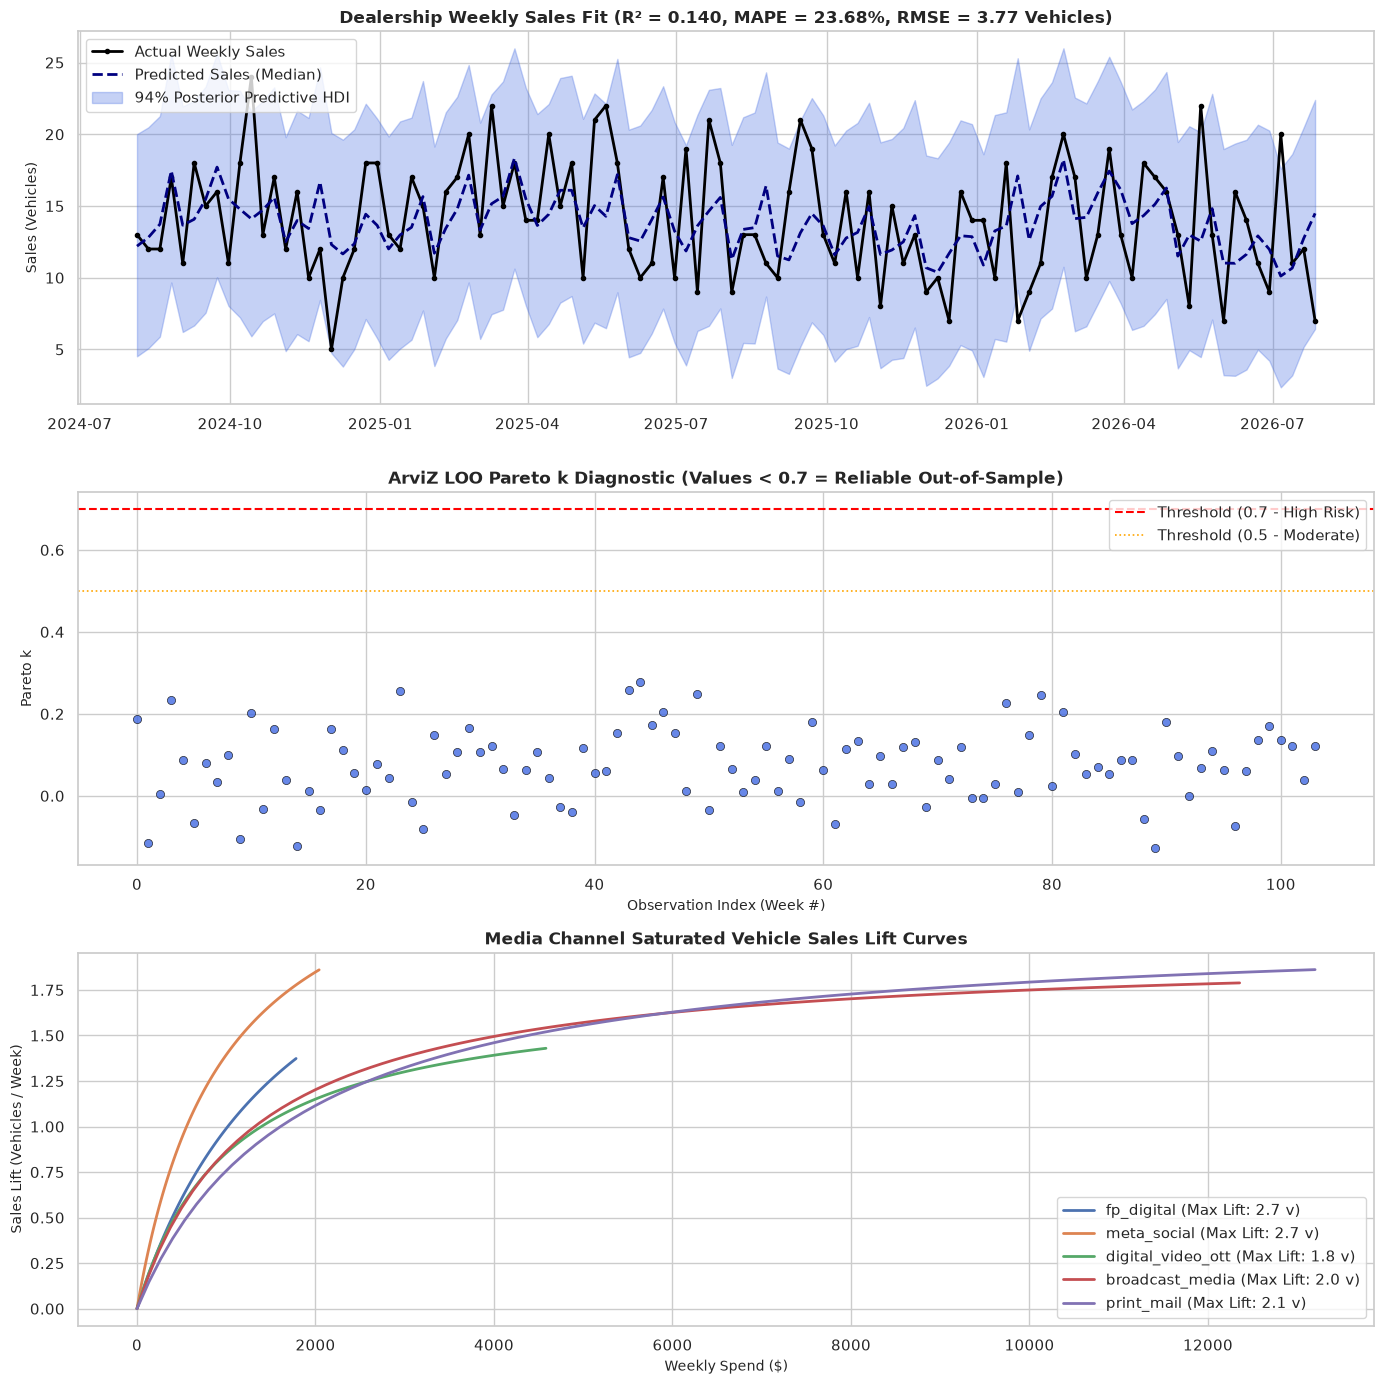

In [25]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# ==============================================================================
# CELL 10: DIAGNOSTICS & 3-PANEL DASHBOARD
# ==============================================================================

media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
sales_mean = df_model['sales'].mean()

print("=" * 80)
print("1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK")
print("=" * 80)

# Check Divergences
divergences = idata.sample_stats["divergences"].values.sum()
print(f"Total Divergent Transitions: {divergences}")
if divergences > 0:
    print("⚠️ WARNING: Divergences detected. Consider increasing target_accept.")
else:
    print("✅ No divergences detected. Sampler geometry is healthy.")

# Summary Table
summary_stats = az.summary(
    idata, 
    var_names=["intercept", "beta_channel", "beta_inv", "beta_eom", "beta_macro", "sigma"]
)

max_rhat = summary_stats["r_hat"].max()
min_ess = summary_stats["ess_bulk"].min()

print(f"Max R-hat (Target <= 1.01): {max_rhat:.3f}")
print(f"Min Bulk ESS (Target > 400): {min_ess:.1f}")

if max_rhat <= 1.01 and min_ess >= 400 and divergences == 0:
    print("🚀 ALL CONVERGENCE CHECKS PASSED!")

display(summary_stats)

# ==============================================================================
# 2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)
# ==============================================================================
print("\n" + "=" * 80)
print("2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)")
print("=" * 80)

ppc_extracted = az.extract(idata, group="posterior_predictive")

if isinstance(ppc_extracted, xr.Dataset):
    if "likelihood" in ppc_extracted:
        ppc_data = ppc_extracted["likelihood"].values
    else:
        first_var = list(ppc_extracted.data_vars)[0]
        ppc_data = ppc_extracted[first_var].values
elif isinstance(ppc_extracted, xr.DataArray):
    ppc_data = ppc_extracted.values
else:
    ppc_data = np.asarray(ppc_extracted)

if ppc_data.shape[0] == len(df_model):
    ppc_samples = ppc_data.T * sales_mean
else:
    ppc_samples = ppc_data * sales_mean

actual_sales = df_model['sales'].values
pred_median = np.median(ppc_samples, axis=0)
pred_lower = np.percentile(ppc_samples, 3, axis=0)   # 94% HDI Lower
pred_upper = np.percentile(ppc_samples, 97, axis=0)  # 94% HDI Upper

mape = np.mean(np.abs((actual_sales - pred_median) / actual_sales)) * 100
rmse = np.sqrt(np.mean((actual_sales - pred_median) ** 2))

ss_res = np.sum((actual_sales - pred_median) ** 2)
ss_tot = np.sum((actual_sales - actual_sales.mean()) ** 2)
r2 = float(1.0 - (ss_res / ss_tot))

print(f"Model R-Squared (R²):                     {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE):    {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE):           {rmse:.2f} vehicles / week")

# ==============================================================================
# 3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)
# ==============================================================================
print("\n" + "=" * 80)
print("3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)")
print("=" * 80)

loo_res = az.loo(idata)

if hasattr(loo_res, "elpd_loo"):
    elpd_val = float(loo_res.elpd_loo)
elif hasattr(loo_res, "elpd"):
    elpd_val = float(loo_res.elpd)
elif "elpd_loo" in loo_res:
    elpd_val = float(loo_res["elpd_loo"])
else:
    elpd_val = float(loo_res["elpd"])

if hasattr(loo_res, "se"):
    se_val = float(loo_res.se)
elif hasattr(loo_res, "se_elpd_loo"):
    se_val = float(loo_res.se_elpd_loo)
else:
    se_val = float(loo_res["se"])

if hasattr(loo_res, "pareto_k"):
    pareto_k_obj = loo_res.pareto_k
elif hasattr(loo_res, "khat"):
    pareto_k_obj = loo_res.khat
else:
    pareto_k_obj = loo_res["pareto_k"]

if hasattr(pareto_k_obj, "values"):
    k_array = pareto_k_obj.values
else:
    k_array = np.asarray(pareto_k_obj)

max_k = float(np.max(k_array))

print(f"ELPD LOO: {elpd_val:.2f} (SE: {se_val:.2f})")
print(f"Max Pareto k (Target < 0.7): {max_k:.2f}")

if max_k < 0.7:
    print("✅ Pareto k values are healthy. Out-of-sample prediction is reliable.")
else:
    print("⚠️ High Pareto k detected. Inspect observations with k > 0.7.")

# ==============================================================================
# 4. 3-PANEL DIAGNOSTIC DASHBOARD
# ==============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
dates = pd.to_datetime(df_model['week_start'])

# Panel 1: Actual vs Predicted Sales Time Series
axes[0].plot(dates, actual_sales, color='black', linewidth=2, label='Actual Weekly Sales', marker='o', markersize=3)
axes[0].plot(dates, pred_median, color='navy', linestyle='--', linewidth=2, label='Predicted Sales (Median)')
axes[0].fill_between(dates, pred_lower, pred_upper, color='royalblue', alpha=0.3, label='94% Posterior Predictive HDI')
axes[0].set_title(f"Dealership Weekly Sales Fit (R² = {r2:.3f}, MAPE = {mape:.2f}%, RMSE = {rmse:.2f} Vehicles)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Sales (Vehicles)", fontsize=10)
axes[0].legend(loc='upper left', frameon=True)

# Panel 2: Pareto k Scatter Diagnostic
axes[1].scatter(np.arange(len(k_array)), k_array, alpha=0.8, color='royalblue', edgecolor='black', linewidth=0.5, s=35)
axes[1].axhline(0.7, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.7 - High Risk)')
axes[1].axhline(0.5, color='orange', linestyle=':', linewidth=1.2, label='Threshold (0.5 - Moderate)')
axes[1].set_title("ArviZ LOO Pareto k Diagnostic (Values < 0.7 = Reliable Out-of-Sample)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Pareto k", fontsize=10)
axes[1].set_xlabel("Observation Index (Week #)", fontsize=10)
axes[1].legend(loc='upper right', frameon=True)

# Panel 3: Pre-Transformed Saturated Lift Curves
post_means = idata.posterior.mean(dim=["chain", "draw"])
beta_means_veh = post_means["beta_channel"].values * sales_mean

if "k_sat" in post_means:
    k_sat_vals = post_means["k_sat"].values
elif "k_val" in post_means:
    k_sat_vals = post_means["k_val"].values
else:
    k_sat_vals = np.ones(len(media_channels))

for i, chan in enumerate(media_channels):
    max_spend = df_model[chan].max() * 1.2
    if max_spend == 0:
        max_spend = 1000.0
    x_grid = np.linspace(0, max_spend, 100)
    c_mean = df_model[chan].mean() if df_model[chan].mean() > 0 else 1.0
    
    x_adstocked = x_grid / c_mean
    k_sat = float(k_sat_vals[i])
    
    y_lift = (x_adstocked / (x_adstocked + k_sat + 1e-8)) * beta_means_veh[i]
    axes[2].plot(x_grid, y_lift, label=f"{chan} (Max Lift: {beta_means_veh[i]:.1f} v)", linewidth=2)

axes[2].set_title("Media Channel Saturated Vehicle Sales Lift Curves", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Sales Lift (Vehicles / Week)", fontsize=10)
axes[2].set_xlabel("Weekly Spend ($)", fontsize=10)
axes[2].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

CHANNEL COST-EFFICIENCY & VEHICLE ACQUISITION TABLE
          Channel Avg Spend ($/Wk) Max Lift (Vehicles) Lift at Avg Spend Cost Per Vehicle ($) Vehicles / $1k Spend
      meta_social          $479.22                2.74              0.91              $527.53                 1.90
  broadcast_media          $621.36                1.97              0.64              $964.97                 1.04
       fp_digital          $921.32                2.73              0.94              $982.01                 1.02
digital_video_ott          $723.57                1.76              0.71            $1,012.94                 0.99
       print_mail        $1,394.69                2.11              0.93            $1,506.89                 0.66


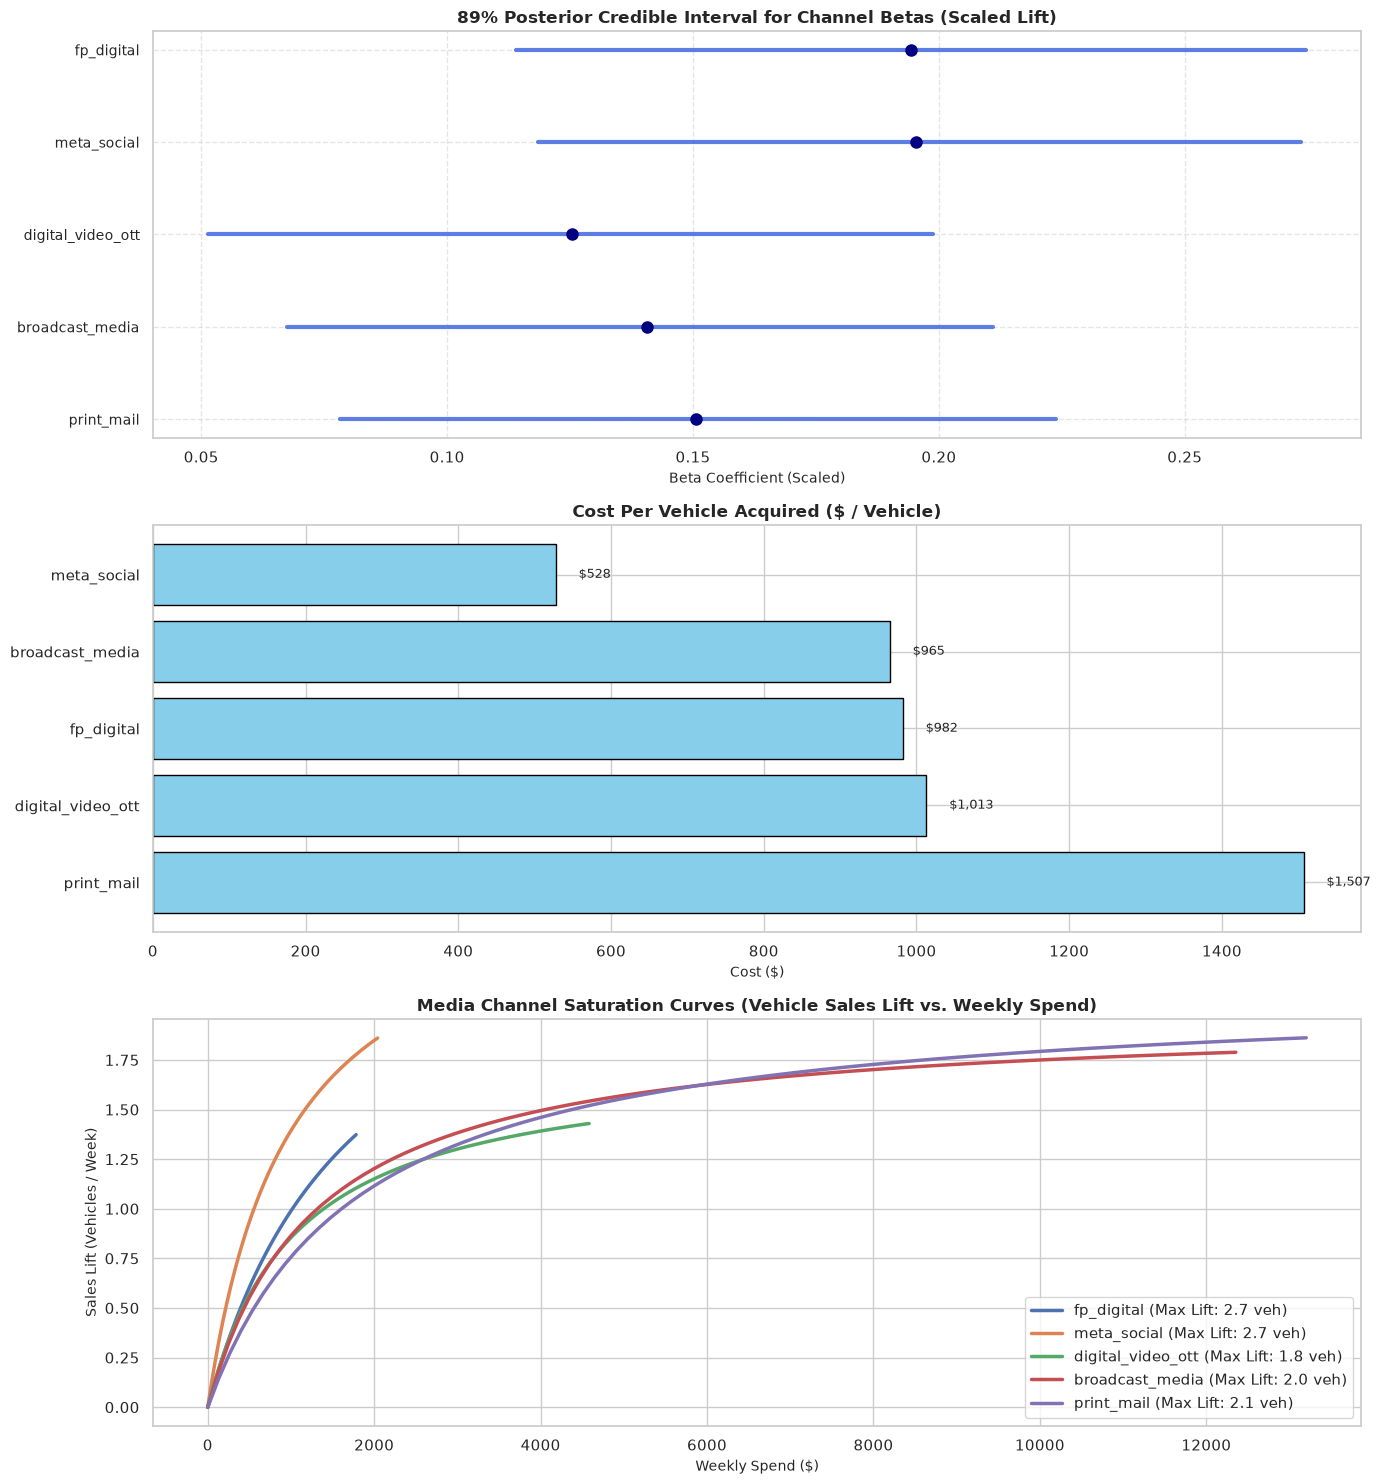

In [26]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# CELL 10: POST-RUN ANALYSIS, CPA TABLE, AND SATURATION DASHBOARD
# ==============================================================================

# 1. Global Scope Channel Definition & Target Mean
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
sales_mean = df_model['sales'].mean()

# 2. Extract Posterior Means
post_means = idata.posterior.mean(dim=["chain", "draw"])
beta_means_veh = post_means["beta_channel"].values * sales_mean

# 3. Calculate Cost Per Vehicle Acquired (CPA) & Acquisition Efficiency Table
efficiency_records = []
for i, chan in enumerate(media_channels):
    avg_spend = df_model[chan].mean()
    if avg_spend == 0:
        avg_spend = 1.0
    
    # Handle coordinate naming safely across PyMC versions
    k_val = float(post_means["k_sat"].values[i]) if "k_sat" in post_means else float(post_means["k_val"].values[i])
    max_lift_veh = float(beta_means_veh[i])
    
    # Evaluate Reach curve at average weekly spend (scaled x = 1.0)
    x_scaled = 1.0
    lift_at_avg = (x_scaled / (x_scaled + k_val + 1e-8)) * max_lift_veh
    
    cost_per_vehicle = avg_spend / (lift_at_avg + 1e-9)
    vehicles_per_1k = (lift_at_avg / avg_spend) * 1000.0 if avg_spend > 0 else 0.0
    
    efficiency_records.append({
        "Channel": chan,
        "Avg Spend ($/Wk)": avg_spend,
        "Max Lift (Vehicles)": max_lift_veh,
        "Lift at Avg Spend": lift_at_avg,
        "Cost Per Vehicle ($)": cost_per_vehicle,
        "Vehicles / $1k Spend": vehicles_per_1k
    })

efficiency_df = pd.DataFrame(efficiency_records).sort_values("Cost Per Vehicle ($)")

print("=" * 80)
print("CHANNEL COST-EFFICIENCY & VEHICLE ACQUISITION TABLE")
print("=" * 80)
print(efficiency_df.to_string(index=False, formatters={
    "Avg Spend ($/Wk)": "${:,.2f}".format,
    "Max Lift (Vehicles)": "{:.2f}".format,
    "Lift at Avg Spend": "{:.2f}".format,
    "Cost Per Vehicle ($)": "${:,.2f}".format,
    "Vehicles / $1k Spend": "{:.2f}".format
}))

# 4. Three-Panel Dashboard
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# --- Panel 1: Version-Proof Native Matplotlib Forest Plot (89% Credible Interval) ---
beta_samples = idata.posterior["beta_channel"].values.reshape(-1, len(media_channels))

for i, chan in enumerate(media_channels):
    chan_samples = beta_samples[:, i]
    mean_val = np.mean(chan_samples)
    low_val = np.percentile(chan_samples, 5.5)   # 89% HDI Lower
    high_val = np.percentile(chan_samples, 94.5) # 89% HDI Upper
    
    y_pos = len(media_channels) - 1 - i
    axes[0].plot([low_val, high_val], [y_pos, y_pos], color='royalblue', linewidth=3, alpha=0.85)
    axes[0].plot(mean_val, y_pos, marker='o', color='navy', markersize=8)

axes[0].set_yticks(np.arange(len(media_channels)))
axes[0].set_yticklabels(reversed(media_channels), fontsize=10)
axes[0].set_title("89% Posterior Credible Interval for Channel Betas (Scaled Lift)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Beta Coefficient (Scaled)", fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Panel 2: Cost Per Vehicle Acquired (Bar Chart) ---
bars = axes[1].barh(efficiency_df["Channel"], efficiency_df["Cost Per Vehicle ($)"], color='skyblue', edgecolor='black')
axes[1].set_title("Cost Per Vehicle Acquired ($ / Vehicle)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Cost ($)", fontsize=10)
axes[1].invert_yaxis()

for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 30, bar.get_y() + bar.get_height()/2, f"${width:,.0f}", ha='left', va='center', fontsize=9)

# --- Panel 3: Pre-Transformed Saturated Lift Curves ---
for i, chan in enumerate(media_channels):
    max_spend = df_model[chan].max() * 1.2
    if max_spend == 0:
        max_spend = 1000.0
    x_spend_grid = np.linspace(0, max_spend, 100)
    
    c_mean = df_model[chan].mean()
    if c_mean == 0:
        c_mean = 1.0
    
    scaled_x = x_spend_grid / c_mean
    k_val = float(post_means["k_sat"].values[i]) if "k_sat" in post_means else float(post_means["k_val"].values[i])
    beta_veh = float(beta_means_veh[i])
    
    y_lift = (scaled_x / (scaled_x + k_val + 1e-8)) * beta_veh
    axes[2].plot(x_spend_grid, y_lift, label=f"{chan} (Max Lift: {beta_veh:.1f} veh)", linewidth=2.5)

axes[2].set_title("Media Channel Saturation Curves (Vehicle Sales Lift vs. Weekly Spend)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Sales Lift (Vehicles / Week)", fontsize=10)
axes[2].set_xlabel("Weekly Spend ($)", fontsize=10)
axes[2].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

ACCURACY METRICS BY REPORTING CADENCE
                    Cadence R-Squared (R²) MAPE (%) RMSE (Vehicles)
       Weekly (Model Input)         0.1398   23.68%       3.77 v/wk
Monthly (Dealership Rollup)         0.5277    8.95%       6.74 v/mo


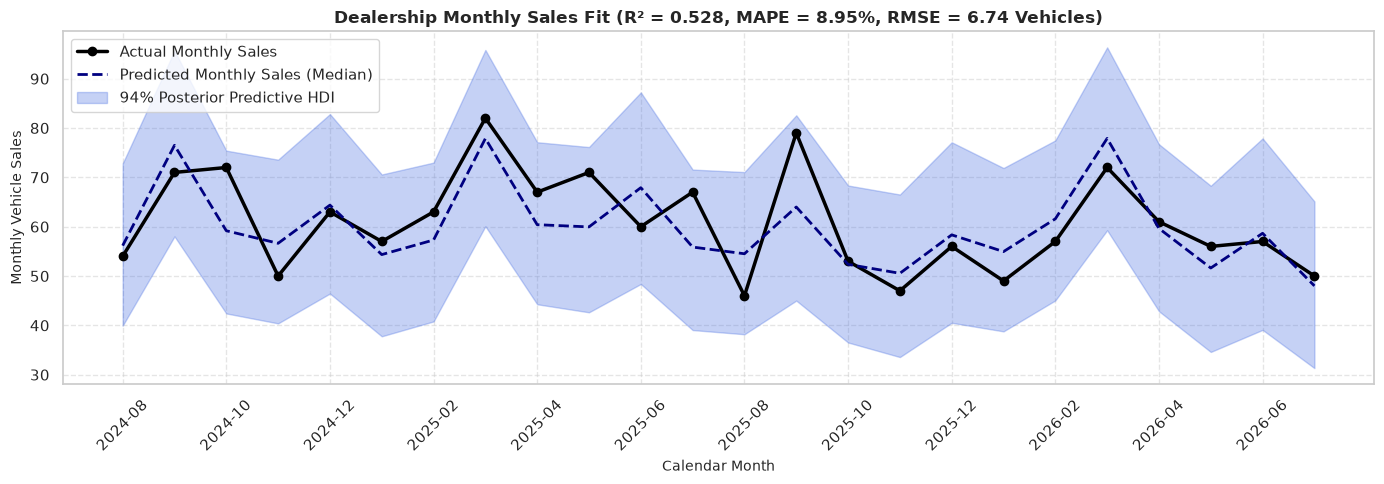

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import xarray as xr

# ==============================================================================
# MONTHLY ROLLED-UP ACCURACY METRICS & DEALERSHIP REPORTING
# ==============================================================================

# 1. Extract Weekly Posterior Predictive Samples in Unscaled Vehicles
ppc_extracted = az.extract(idata, group="posterior_predictive")

if isinstance(ppc_extracted, xr.Dataset):
    ppc_key = "likelihood" if "likelihood" in ppc_extracted else list(ppc_extracted.data_vars)[0]
    ppc_data = ppc_extracted[ppc_key].values
elif isinstance(ppc_extracted, xr.DataArray):
    ppc_data = ppc_extracted.values
else:
    ppc_data = np.asarray(ppc_extracted)

# Align shape to (n_weeks, n_draws) and unscale
if ppc_data.shape[0] == len(df_model):
    weekly_draws = ppc_data * sales_mean
else:
    weekly_draws = ppc_data.T * sales_mean

# 2. Build Weekly DataFrame with Draw Matrices
df_weekly_eval = df_model[['week_start', 'sales']].copy()
df_weekly_eval['year_month'] = pd.to_datetime(df_weekly_eval['week_start']).dt.to_period('M')

# Group Actuals and Draw Matrices by Calendar Month
monthly_groups = df_weekly_eval.groupby('year_month')
month_periods = list(monthly_groups.groups.keys())
n_months = len(month_periods)
n_draws = weekly_draws.shape[1]

monthly_actuals = np.zeros(n_months)
monthly_draws = np.zeros((n_months, n_draws))

for i, (m, indices) in enumerate(monthly_groups.groups.items()):
    monthly_actuals[i] = df_weekly_eval.loc[indices, 'sales'].sum()
    monthly_draws[i, :] = weekly_draws[indices, :].sum(axis=0)

# 3. Monthly Posterior Summaries
monthly_pred_median = np.median(monthly_draws, axis=1)
monthly_pred_lower = np.percentile(monthly_draws, 3, axis=1)   # 94% HDI Lower
monthly_pred_upper = np.percentile(monthly_draws, 97, axis=1)  # 94% HDI Upper

# 4. Monthly Accuracy Metrics
monthly_mape = np.mean(np.abs((monthly_actuals - monthly_pred_median) / monthly_actuals)) * 100
monthly_rmse = np.sqrt(np.mean((monthly_actuals - monthly_pred_median) ** 2))

ss_res_m = np.sum((monthly_actuals - monthly_pred_median) ** 2)
ss_tot_m = np.sum((monthly_actuals - np.mean(monthly_actuals)) ** 2)
monthly_r2 = float(1.0 - (ss_res_m / ss_tot_m))

# Weekly Metrics for Comparison (from Cell 10)
weekly_pred_median = np.median(weekly_draws, axis=1)
weekly_actuals = df_weekly_eval['sales'].values
weekly_mape = np.mean(np.abs((weekly_actuals - weekly_pred_median) / weekly_actuals)) * 100
weekly_rmse = np.sqrt(np.mean((weekly_actuals - weekly_pred_median) ** 2))
weekly_r2 = 1.0 - (np.sum((weekly_actuals - weekly_pred_median)**2) / np.sum((weekly_actuals - weekly_actuals.mean())**2))

# 5. Summary Table
cadence_comparison = pd.DataFrame({
    "Cadence": ["Weekly (Model Input)", "Monthly (Dealership Rollup)"],
    "R-Squared (R²)": [f"{weekly_r2:.4f}", f"{monthly_r2:.4f}"],
    "MAPE (%)": [f"{weekly_mape:.2f}%", f"{monthly_mape:.2f}%"],
    "RMSE (Vehicles)": [f"{weekly_rmse:.2f} v/wk", f"{monthly_rmse:.2f} v/mo"]
})

print("=" * 80)
print("ACCURACY METRICS BY REPORTING CADENCE")
print("=" * 80)
print(cadence_comparison.to_string(index=False))

# 6. Plot Monthly Actuals vs Predicted Fit
plt.figure(figsize=(14, 5))
month_labels = [str(m) for m in month_periods]
x_axis = np.arange(n_months)

plt.plot(x_axis, monthly_actuals, color='black', linewidth=2.5, marker='o', label='Actual Monthly Sales')
plt.plot(x_axis, monthly_pred_median, color='navy', linestyle='--', linewidth=2, label='Predicted Monthly Sales (Median)')
plt.fill_between(x_axis, monthly_pred_lower, monthly_pred_upper, color='royalblue', alpha=0.3, label='94% Posterior Predictive HDI')

plt.title(f"Dealership Monthly Sales Fit (R² = {monthly_r2:.3f}, MAPE = {monthly_mape:.2f}%, RMSE = {monthly_rmse:.2f} Vehicles)", fontsize=12, fontweight='bold')
plt.ylabel("Monthly Vehicle Sales", fontsize=10)
plt.xlabel("Calendar Month", fontsize=10)
plt.xticks(x_axis[::2], month_labels[::2], rotation=45)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import pandas as pd
import arviz as az
from scipy.optimize import minimize

# ==============================================================================
# MONTHLY MEDIA BUDGET OPTIMIZER & MARGINAL ROAS (mROAS) ANALYSIS
# ==============================================================================

# 1. Setup Channel Parameters & Posterior Means
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
sales_mean = df_model['sales'].mean()
post_means = idata.posterior.mean(dim=["chain", "draw"])

# Extract Posterior Mean Parameters
beta_means = post_means["beta_channel"].values * sales_mean
k_sat_means = post_means["k_sat"].values if "k_sat" in post_means else post_means["k_val"].values
s_slope_means = post_means["s_slope"].values if "s_slope" in post_means else np.ones(len(media_channels))
alpha_means = post_means["alpha"].values if "alpha" in post_means else np.array([0.15, 0.25, 0.40, 0.50, 0.60])

# Historical Weekly Averages
weekly_c_means = np.array([df_model[c].mean() if df_model[c].mean() > 0 else 1.0 for c in media_channels])

# 2. Monthly Budget Horizon Configuration
# W_weeks: 4.33 for standard calendar month, or set to 4 / 5 for NADA/broadcast calendar months
W_weeks = 4.3333

current_weekly_spends = np.array([df_model[c].mean() for c in media_channels])
current_monthly_spends = current_weekly_spends * W_weeks
total_monthly_budget = np.sum(current_monthly_spends)

# 3. Monthly Response & Lift Calculation
def calculate_monthly_channel_lifts(monthly_spends, weeks_in_month=W_weeks):
    """Calculates monthly vehicle sales lift for given monthly channel budgets."""
    weekly_spends = monthly_spends / weeks_in_month
    
    # Evaluate carryover-adjusted weekly lift and aggregate over W weeks
    monthly_lifts = np.zeros(len(media_channels))
    for m in range(len(media_channels)):
        s_w = weekly_spends[m]
        a_m = alpha_means[m]
        
        # 1-week equilibrium adstock factor: s_adstocked = s_w / (1 - a_m)
        s_adstocked = s_w / (1.0 - a_m + 1e-8)
        x_scaled = s_adstocked / weekly_c_means[m]
        
        s = s_slope_means[m]
        k = k_sat_means[m]
        
        x_s = np.power(x_scaled, s)
        k_s = np.power(k, s)
        
        weekly_lift = (x_s / (x_s + k_s + 1e-8)) * beta_means[m]
        monthly_lifts[m] = weekly_lift * weeks_in_month
        
    return monthly_lifts

def objective_neg_monthly_lift(monthly_spends):
    return -np.sum(calculate_monthly_channel_lifts(monthly_spends))

def calculate_monthly_mroas(monthly_spends, delta=1000.0):
    """Calculates Monthly Marginal ROAS (vehicles per $1,000 monthly spend increment)."""
    base_lifts = calculate_monthly_channel_lifts(monthly_spends)
    mroas_list = []
    for i in range(len(monthly_spends)):
        spends_plus = monthly_spends.copy()
        spends_plus[i] += delta
        lift_plus = calculate_monthly_channel_lifts(spends_plus)[i]
        mroas = ((lift_plus - base_lifts[i]) / delta) * 1000.0
        mroas_list.append(mroas)
    return np.array(mroas_list)

# 4. Multi-Start SLSQP Optimization over Monthly Budget Simplex
constraints = ({'type': 'eq', 'fun': lambda b: np.sum(b) - total_monthly_budget})
bounds = [(0.0, total_monthly_budget * 0.50) for _ in media_channels]  # Max 50% cap per channel

best_lift = -np.inf
best_opt_res = None

np.random.seed(42)
initial_seeds = [current_monthly_spends] + [
    np.random.dirichlet(np.ones(len(media_channels))) * total_monthly_budget for _ in range(50)
]

for seed in initial_seeds:
    res = minimize(
        objective_neg_monthly_lift,
        seed,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'eps': 50.0, 'ftol': 1e-9, 'maxiter': 500}  # $50 finite-difference step size for monthly scale
    )
    lift = -res.fun
    if lift > best_lift and res.success:
        best_lift = lift
        best_opt_res = res

opt_monthly_spends = best_opt_res.x

# 5. Compute Monthly Metrics & Summary DataFrame
current_monthly_lifts = calculate_monthly_channel_lifts(current_monthly_spends)
opt_monthly_lifts = calculate_monthly_channel_lifts(opt_monthly_spends)

current_mroas = calculate_monthly_mroas(current_monthly_spends)
opt_mroas = calculate_monthly_mroas(opt_monthly_spends)

monthly_summary_df = pd.DataFrame({
    "Channel": media_channels,
    "Current Monthly Spend ($)": current_monthly_spends,
    "Optimal Monthly Spend ($)": opt_monthly_spends,
    "Net Monthly Shift ($)": opt_monthly_spends - current_monthly_spends,
    "Current Monthly Lift (Veh)": current_monthly_lifts,
    "Optimal Monthly Lift (Veh)": opt_monthly_lifts,
    "Current mROAS ($1k)": current_mroas,
    "Optimal mROAS ($1k)": opt_mroas
})

initial_total_monthly_lift = np.sum(current_monthly_lifts)
opt_total_monthly_lift = np.sum(opt_monthly_lifts)

print("=" * 95)
print(f"MONTHLY BUDGET OPTIMIZATION (TOTAL MONTHLY BUDGET: ${total_monthly_budget:,.2f} | HORIZON: {W_weeks:.2f} WEEKS)")
print("=" * 95)
print(monthly_summary_df.to_string(index=False, formatters={
    "Current Monthly Spend ($)": "${:,.2f}".format,
    "Optimal Monthly Spend ($)": "${:,.2f}".format,
    "Net Monthly Shift ($)": "${:+,.2f}".format,
    "Current Monthly Lift (Veh)": "{:.2f}".format,
    "Optimal Monthly Lift (Veh)": "{:.2f}".format,
    "Current mROAS ($1k)": "{:.3f} v".format,
    "Optimal mROAS ($1k)": "{:.3f} v".format
}))

print("\n" + "-" * 95)
print(f"Current Attributable Monthly Sales Lift  : {initial_total_monthly_lift:.2f} vehicles / month")
print(f"Optimized Attributable Monthly Sales Lift: {opt_total_monthly_lift:.2f} vehicles / month")
print(f"Projected Monthly Incremental Vehicle Gain: +{opt_total_monthly_lift - initial_total_monthly_lift:.2f} vehicles / month ({((opt_total_monthly_lift/initial_total_monthly_lift)-1)*100:+.1f}%)")
print(f"Projected Annual Incremental Vehicle Gain : +{(opt_total_monthly_lift - initial_total_monthly_lift) * (12.0 / (W_weeks / 4.3333)):.1f} vehicles / year")
print("-" * 95)

MONTHLY BUDGET OPTIMIZATION (TOTAL MONTHLY BUDGET: $17,940.55 | HORIZON: 4.33 WEEKS)
          Channel Current Monthly Spend ($) Optimal Monthly Spend ($) Net Monthly Shift ($) Current Monthly Lift (Veh) Optimal Monthly Lift (Veh) Current mROAS ($1k) Optimal mROAS ($1k)
       fp_digital                 $3,992.35                 $5,155.72            $+1,163.37                       4.10                       5.04             0.815 v             0.680 v
      meta_social                 $2,076.60                 $3,625.66            $+1,549.05                       4.84                       6.32             1.042 v             0.644 v
digital_video_ott                 $3,135.45                 $3,130.34                $-5.11                       4.11                       4.11             0.625 v             0.626 v
  broadcast_media                 $2,692.53                 $3,271.40              $+578.87                       4.20                       4.67             0.763 v      

In [29]:
import numpy as np
import pandas as pd
import arviz as az
from scipy.optimize import minimize

# ==============================================================================
# INTERACTIVE MONTHLY DEALERSHIP SCENARIO BUILDER
# ==============================================================================

class DealershipScenarioBuilder:
    """
    Interactive Scenario Planning Engine for Titan Chrysler/Jeep Dealership.
    Simulates monthly budget reallocations, contractual locks, budget scaling,
    and vehicle target optimization while preserving Bayesian adstock/saturation parameters.
    """
    def __init__(self, idata, df_model, media_channels, weeks_in_month=4.3333):
        self.idata = idata
        self.df_model = df_model
        self.media_channels = media_channels
        self.W = weeks_in_month
        self.sales_mean = df_model['sales'].mean()
        
        # Extract Posterior Means
        post_means = idata.posterior.mean(dim=["chain", "draw"])
        self.beta_means = post_means["beta_channel"].values * self.sales_mean
        self.k_sat_means = post_means["k_sat"].values if "k_sat" in post_means else post_means["k_val"].values
        self.s_slope_means = post_means["s_slope"].values if "s_slope" in post_means else np.ones(len(media_channels))
        
        # Channel-specific adstock decay rates (alpha)
        if "alpha" in post_means:
            self.alpha_means = post_means["alpha"].values
        else:
            # Fallback to defaults if alpha is pre-adstocked
            self.alpha_means = np.array([0.1445, 0.1019, 0.2022, 0.5047, 0.5053])

        self.c_means = np.array([df_model[c].mean() if df_model[c].mean() > 0 else 1.0 for c in media_channels])
        self.historical_weekly_spend = np.array([df_model[c].mean() for c in media_channels])
        self.historical_monthly_spend = self.historical_weekly_spend * self.W

    def _calculate_channel_lifts(self, monthly_spends):
        """Computes monthly vehicle sales lift using equilibrium adstock transformation."""
        weekly_spends = monthly_spends / self.W
        monthly_lifts = np.zeros(len(self.media_channels))
        
        for m in range(len(self.media_channels)):
            s_w = weekly_spends[m]
            a_m = self.alpha_means[m]
            
            # Carryover equilibrium adstock multiplier: 1 / (1 - alpha)
            s_adstocked = s_w / (1.0 - a_m + 1e-8)
            x_scaled = s_adstocked / self.c_means[m]
            
            s = self.s_slope_means[m]
            k = self.k_sat_means[m]
            
            x_s = np.power(x_scaled, s)
            k_s = np.power(k, s)
            
            weekly_lift = (x_s / (x_s + k_s + 1e-8)) * self.beta_means[m]
            monthly_lifts[m] = weekly_lift * self.W
            
        return monthly_lifts

    def simulate_budget_scenario(self, total_monthly_budget, locked_spends=None, max_channel_shares=None):
        """
        Optimizes spend for an arbitrary total monthly budget with optional channel locks and caps.
        
        Parameters:
        -----------
        total_monthly_budget : float
            Total monthly budget ($) to optimize.
        locked_spends : dict, optional
            Channels with fixed monthly budgets, e.g. {'broadcast_media': 3500.0}
        max_channel_shares : dict, optional
            Maximum allowed share of total budget per channel, e.g. {'fp_digital': 0.40}
        """
        if locked_spends is None:
            locked_spends = {}
        if max_channel_shares is None:
            max_channel_shares = {c: 0.50 for c in self.media_channels} # Default 50% max cap

        # Formulate Bounds
        bounds = []
        for i, chan in enumerate(self.media_channels):
            if chan in locked_spends:
                fixed_val = locked_spends[chan]
                bounds.append((fixed_val, fixed_val))
            else:
                max_cap = max_channel_shares.get(chan, 0.50) * total_monthly_budget
                bounds.append((0.0, max_cap))

        constraints = ({'type': 'eq', 'fun': lambda b: np.sum(b) - total_monthly_budget})

        # Objective: Minimize negative total vehicle lift
        def objective(spends):
            return -np.sum(self._calculate_channel_lifts(spends))

        # Multi-Start Optimization
        best_lift = -np.inf
        best_res = None
        np.random.seed(42)
        
        seeds = [self.historical_monthly_spend] + [
            np.random.dirichlet(np.ones(len(self.media_channels))) * total_monthly_budget for _ in range(30)
        ]

        for seed in seeds:
            # Adjust seed to respect fixed bounds
            adjusted_seed = seed.copy()
            for chan_idx, chan_name in enumerate(self.media_channels):
                if chan_name in locked_spends:
                    adjusted_seed[chan_idx] = locked_spends[chan_name]

            res = minimize(
                objective,
                adjusted_seed,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                options={'eps': 50.0, 'ftol': 1e-9, 'maxiter': 500}
            )
            
            if res.success and (-res.fun > best_lift):
                best_lift = -res.fun
                best_res = res

        opt_spends = best_res.x
        current_lifts = self._calculate_channel_lifts(self.historical_monthly_spend)
        opt_lifts = self._calculate_channel_lifts(opt_spends)

        # Build Output DataFrame
        scenario_df = pd.DataFrame({
            "Channel": self.media_channels,
            "Historical Spend ($)": self.historical_monthly_spend,
            "Simulated Spend ($)": opt_spends,
            "Net Shift ($)": opt_spends - self.historical_monthly_spend,
            "Historical Lift (Veh)": current_lifts,
            "Simulated Lift (Veh)": opt_lifts,
            "Channel Status": ["Locked" if c in locked_spends else "Optimized" for c in self.media_channels]
        })

        hist_total_lift = np.sum(current_lifts)
        sim_total_lift = np.sum(opt_lifts)
        inc_gain = sim_total_lift - hist_total_lift

        print("=" * 95)
        print(f"DEALERSHIP SCENARIO SIMULATION | MONTHLY BUDGET: ${total_monthly_budget:,.2f}")
        print("=" * 95)
        print(scenario_df.to_string(index=False, formatters={
            "Historical Spend ($)": "${:,.2f}".format,
            "Simulated Spend ($)": "${:,.2f}".format,
            "Net Shift ($)": "${:+,.2f}".format,
            "Historical Lift (Veh)": "{:.2f} v".format,
            "Simulated Lift (Veh)": "{:.2f} v".format
        }))

        print("\n" + "-" * 95)
        print(f"Historical Attributable Lift : {hist_total_lift:.2f} vehicles / month")
        print(f"Simulated Attributable Lift  : {sim_total_lift:.2f} vehicles / month")
        print(f"Projected Incremental Gain   : {inc_gain:+,.2f} vehicles / month ({((sim_total_lift/hist_total_lift)-1)*100:+.1f}%)")
        print(f"Projected Annual Impact      : {inc_gain * 12.0:+,.1f} vehicles / year")
        print("-" * 95)

        return scenario_df


# ==============================================================================
# EXECUTE SCENARIO EXAMPLES
# ==============================================================================

# Instantiate Scenario Engine
scenario_engine = DealershipScenarioBuilder(idata, df_model, media_channels)

# SCENARIO A: What if monthly budget increases by +20% (to $21,528/mo)?
print("\n>>> RUNNING SCENARIO A: +20% BUDGET EXPANSION ($21,528 / Month) <<<")
scenario_A = scenario_engine.simulate_budget_scenario(
    total_monthly_budget=21528.00
)

# SCENARIO B: Lock Broadcast Media at $3,500/mo (TV Contract) and optimize the rest ($17,940 Total)
print("\n>>> RUNNING SCENARIO B: CONTRACTUAL LOCK ON BROADCAST MEDIA ($3,500 Locked) <<<")
scenario_B = scenario_engine.simulate_budget_scenario(
    total_monthly_budget=17940.69,
    locked_spends={'broadcast_media': 3500.00}
)


>>> RUNNING SCENARIO A: +20% BUDGET EXPANSION ($21,528 / Month) <<<
DEALERSHIP SCENARIO SIMULATION | MONTHLY BUDGET: $21,528.00
          Channel Historical Spend ($) Simulated Spend ($) Net Shift ($) Historical Lift (Veh) Simulated Lift (Veh) Channel Status
       fp_digital            $3,992.35           $6,300.60    $+2,308.25                4.08 v               5.78 v      Optimized
      meta_social            $2,076.60           $4,340.43    $+2,263.83                4.38 v               6.32 v      Optimized
digital_video_ott            $3,135.45           $3,772.75      $+637.31                3.45 v               3.88 v      Optimized
  broadcast_media            $2,692.53           $3,812.46    $+1,119.93                4.22 v               5.06 v      Optimized
       print_mail            $6,043.62           $3,301.76    $-2,741.86                5.49 v               4.27 v      Optimized

------------------------------------------------------------------------------------

In [30]:
import numpy as np
import pandas as pd
import arviz as az

# ==============================================================================
# ETHICAL SCENARIO REPORT GENERATOR WITH VERSION-SAFE ARVIZ HDI (PROB=0.89)
# ==============================================================================

def generate_ethical_dealer_report(scenario_engine, target_monthly_budget=21528.00, n_mc_draws=200):
    """
    Simulates Scenario A across posterior draws to generate point medians 
    and 89% Credible Intervals (HDI) for ethical leadership reporting.
    Compatible with ArViZ 1.0+ (arviz-stats) and legacy ArViZ releases.
    """
    media_channels = scenario_engine.media_channels
    W = scenario_engine.W
    sales_mean = scenario_engine.sales_mean
    
    # Extract raw posterior draws
    post_draws = az.extract(scenario_engine.idata, combined=True)
    n_total_draws = post_draws.sizes['sample']
    
    np.random.seed(42)
    draw_indices = np.random.choice(n_total_draws, size=n_mc_draws, replace=False)
    
    beta_draws = post_draws["beta_channel"].values[:, draw_indices] * sales_mean
    k_sat_draws = post_draws["k_sat"].values[:, draw_indices] if "k_sat" in post_draws else post_draws["k_val"].values[:, draw_indices]
    s_slope_draws = post_draws["s_slope"].values[:, draw_indices] if "s_slope" in post_draws else np.ones((len(media_channels), n_mc_draws))
    alpha_draws = post_draws["alpha"].values[:, draw_indices] if "alpha" in post_draws else np.tile(scenario_engine.alpha_means[:, None], (1, n_mc_draws))
    
    hist_spends = scenario_engine.historical_monthly_spend
    
    # Run simulation for Point Estimate (Posterior Means)
    mean_scenario = scenario_engine.simulate_budget_scenario(target_monthly_budget)
    opt_spends_mean = mean_scenario["Simulated Spend ($)"].values
    
    # Propagate Uncertainty across Draw Tensors
    hist_lifts_draws = np.zeros(n_mc_draws)
    sim_lifts_draws = np.zeros(n_mc_draws)
    
    for d in range(n_mc_draws):
        def draw_lift(spends):
            weekly_spends = spends / W
            total = 0.0
            for m in range(len(media_channels)):
                s_w = weekly_spends[m]
                a_m = alpha_draws[m, d]
                s_adstocked = s_w / (1.0 - a_m + 1e-8)
                x_scaled = s_adstocked / scenario_engine.c_means[m]
                s = s_slope_draws[m, d]
                k = k_sat_draws[m, d]
                
                x_s = np.power(x_scaled, s)
                k_s = np.power(k, s)
                total += (x_s / (x_s + k_s + 1e-8)) * beta_draws[m, d] * W
            return total
            
        hist_lifts_draws[d] = draw_lift(hist_spends)
        sim_lifts_draws[d] = draw_lift(opt_spends_mean)
        
    inc_monthly_draws = sim_lifts_draws - hist_lifts_draws
    inc_annual_draws = inc_monthly_draws * 12.0
    
    # Version-safe 89% HDI Helper (Handles ArViZ 1.0+ 'prob' vs legacy 'hdi_prob')
    def fmt_hdi(arr, fmt="{:.1f}"):
        try:
            hdi = az.hdi(arr, prob=0.89)
        except TypeError:
            hdi = az.hdi(arr, hdi_prob=0.89)
        return f"[{fmt.format(hdi[0])} to {fmt.format(hdi[1])}]"
        
    print("\n" + "=" * 90)
    print("ETHICAL EXECUTIVE REPORT: SCENARIO A (+20% EXPANSION WITH UNCERTAINTY)")
    print("=" * 90)
    print(f"Target Monthly Budget       : ${target_monthly_budget:,.2f} (Expansion: +${target_monthly_budget - np.sum(hist_spends):,.2f})")
    print(f"Historical Monthly Sales Lift: {np.median(hist_lifts_draws):.2f} v/mo (89% HDI: {fmt_hdi(hist_lifts_draws)})")
    print(f"Simulated Monthly Sales Lift : {np.median(sim_lifts_draws):.2f} v/mo (89% HDI: {fmt_hdi(sim_lifts_draws)})")
    print(f"Projected Monthly Gain       : +{np.median(inc_monthly_draws):.2f} v/mo (89% HDI: {fmt_hdi(inc_monthly_draws, '{:+.2f}')})")
    print(f"Projected Annual Gain        : +{np.median(inc_annual_draws):.1f} v/yr (89% HDI: {fmt_hdi(inc_annual_draws, '{:+.1f}')})")
    print("-" * 90)

# Run Ethical Summary
generate_ethical_dealer_report(scenario_engine, target_monthly_budget=21528.00)

DEALERSHIP SCENARIO SIMULATION | MONTHLY BUDGET: $21,528.00
          Channel Historical Spend ($) Simulated Spend ($) Net Shift ($) Historical Lift (Veh) Simulated Lift (Veh) Channel Status
       fp_digital            $3,992.35           $6,300.60    $+2,308.25                4.08 v               5.78 v      Optimized
      meta_social            $2,076.60           $4,340.43    $+2,263.83                4.38 v               6.32 v      Optimized
digital_video_ott            $3,135.45           $3,772.75      $+637.31                3.45 v               3.88 v      Optimized
  broadcast_media            $2,692.53           $3,812.46    $+1,119.93                4.22 v               5.06 v      Optimized
       print_mail            $6,043.62           $3,301.76    $-2,741.86                5.49 v               4.27 v      Optimized

-----------------------------------------------------------------------------------------------
Historical Attributable Lift : 21.63 vehicles / month
Sim

In [31]:
import pandas as pd
import numpy as np

# ==============================================================================
# SINGLE-ROOFTOP PHASED ROLLOUT SCHEDULE GENERATOR
# ==============================================================================

def create_phased_rollout_schedule(scenario_df, phase_ratio=0.50):
    """
    Generates a 50% conservative pilot reallocation schedule for a single rooftop.
    """
    rollout_df = scenario_df.copy()
    rollout_df["Net Shift ($)"] = pd.to_numeric(rollout_df["Net Shift ($)"].astype(str).str.replace('$', '').str.replace(',', '').str.replace('+', ''))
    rollout_df["Historical Spend ($)"] = pd.to_numeric(rollout_df["Historical Spend ($)"].astype(str).str.replace('$', '').str.replace(',', ''))
    
    # Calculate Phase 1 Pilot Spend (50% Shift)
    rollout_df["Phase 1 Pilot Spend ($)"] = rollout_df["Historical Spend ($)"] + (rollout_df["Net Shift ($)"] * phase_ratio)
    rollout_df["Phase 1 Weekly Spend ($)"] = rollout_df["Phase 1 Pilot Spend ($)"] / 4.3333
    
    output_table = rollout_df[["Channel", "Historical Spend ($)", "Phase 1 Pilot Spend ($)", "Phase 1 Weekly Spend ($)"]]
    
    print("=" * 85)
    print(f"SINGLE-ROOFTOP PHASE 1 PILOT SCHEDULE ({int(phase_ratio*100)}% REALLOCATION STEP)")
    print("=" * 85)
    print(output_table.to_string(index=False, formatters={
        "Historical Spend ($)": "${:,.2f}".format,
        "Phase 1 Pilot Spend ($)": "${:,.2f}".format,
        "Phase 1 Weekly Spend ($)": "${:,.2f}/wk".format
    }))
    print("-" * 85)

# Execute Schedule Generator
create_phased_rollout_schedule(scenario_A, phase_ratio=0.50)

SINGLE-ROOFTOP PHASE 1 PILOT SCHEDULE (50% REALLOCATION STEP)
          Channel Historical Spend ($) Phase 1 Pilot Spend ($) Phase 1 Weekly Spend ($)
       fp_digital            $3,992.35               $5,146.47             $1,187.66/wk
      meta_social            $2,076.60               $3,208.52               $740.43/wk
digital_video_ott            $3,135.45               $3,454.10               $797.11/wk
  broadcast_media            $2,692.53               $3,252.49               $750.58/wk
       print_mail            $6,043.62               $4,672.69             $1,078.32/wk
-------------------------------------------------------------------------------------


In [32]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

# ==============================================================================
# BUILD AND SAMPLE TIME-VARYING PARAMETER (idata_tvp) MODEL
# ==============================================================================

# Updated Optuna Arrays
optuna_alpha   = np.array([0.2434, 0.2588, 0.2088, 0.4936, 0.4918])
optuna_lmax    = np.array([4, 3, 7, 5, 6], dtype=int)
optuna_ksat    = np.array([1.8949, 2.0182, 1.4515, 2.0235, 1.3025])
optuna_slope   = np.array([1.3476, 0.9615, 1.1856, 1.1618, 0.8378])
optuna_beta_mu = np.array([0.1985, 0.2015, 0.1290, 0.1473, 0.1272])

intercept_mu_val = 0.6498
beta_eom_mu_val  = 0.3641

media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

n_obs = len(df_model)
n_media = len(media_channels)
sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

# Pre-adstocked media matrix
adstocked_media_list = []
for m, chan in enumerate(media_channels):
    a_m = optuna_alpha[m]
    l_m = optuna_lmax[m]
    c_mean = df_model[chan].mean()
    x_raw = (df_model[chan] / (c_mean if c_mean > 0 else 1.0)).values
    
    lags_m = np.arange(l_m)
    weights_m = np.power(a_m, lags_m)
    weights_m /= weights_m.sum()
    
    x_lag_m = np.zeros((n_obs, l_m))
    for l in range(l_m):
        x_lag_m[:, l] = np.pad(x_raw, (l, 0))[:n_obs]
        
    adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
    adstocked_media_list.append(adstocked_m)

X_adstocked_optuna = np.column_stack(adstocked_media_list)

# PyMC TVP Model Construction
with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": media_channels,
    "fourier_term": fourier_cols
}) as tvp_model:

    # Data Containers
    adstocked_data = pm.Data("adstocked_data", X_adstocked_optuna, dims=("obs_id", "channel"))
    fourier_data = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
    inv_data = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")

    # Controls
    intercept = pm.Normal("intercept", mu=0.6331, sigma=0.08)
    b_eom = pm.TruncatedNormal("beta_eom", mu=0.3792, sigma=0.10, lower=0.0)
    b_inv = pm.HalfNormal("beta_inv", sigma=0.10)
    b_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, dims="fourier_term")

    # Saturation Priors
    k_sat = pm.Gamma("k_sat", alpha=optuna_ksat * 10, beta=10, dims="channel")
    s_slope = pm.Gamma("s_slope", alpha=optuna_slope * 10, beta=10, dims="channel")

    # Time-Varying Betas (Gaussian Random Walk)
    sigma_beta = pm.Exponential("sigma_beta", lam=20.0, dims="channel")
    beta_innovations = pm.Normal("beta_innovations", mu=0, sigma=1, dims=("obs_id", "channel"))
    
    beta_raw = pm.math.cumsum(beta_innovations * sigma_beta, axis=0)
    beta_base = pm.Normal("beta_base", mu=optuna_beta_mu, sigma=0.05, dims="channel")
    
    beta_channel_t = pm.Deterministic("beta_channel_t", pt.softplus(beta_base + beta_raw), dims=("obs_id", "channel"))

    # Hill Transformation with Time-Varying Betas
    media_sat = (adstocked_data ** s_slope) / (adstocked_data ** s_slope + k_sat ** s_slope + 1e-8)
    media_contrib = pt.sum(media_sat * beta_channel_t, axis=1)

    mu = intercept + media_contrib + (b_inv * inv_data) + (b_eom * eom_data) + pm.math.dot(fourier_data, b_fourier)
    pm.StudentT("likelihood", nu=7, mu=mu, sigma=pm.Exponential("sigma", lam=10.0), observed=y_scaled, dims="obs_id")

# Sample MCMC & Posterior Predictive
with tvp_model:
    print("🚀 Sampling TVP Model (idata_tvp)...")
    idata_tvp = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.98, random_seed=42)
    pm.sample_posterior_predictive(idata_tvp, extend_inferencedata=True, random_seed=42)

print("✅ idata_tvp sampled and ready for comparison!")

🚀 Sampling TVP Model (idata_tvp)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_eom, beta_inv, beta_fourier, k_sat, s_slope, sigma_beta, beta_innovations, beta_base, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 77 seconds.
Sampling: [likelihood]


✅ idata_tvp sampled and ready for comparison!


DEALERSHIP COMMERCIAL ATTRIBUTION & ACQUISITION EFFICIENCY TABLE
          Channel Avg Spend ($/Wk) Share of Spend (%) Weekly Lift Median (Veh) 89% HDI Weekly Lift CPA Median ($/Veh)   89% HDI CPA ($) Share of Lift (%)
      meta_social          $479.22              11.6%                0.89 v/wk       [0.47 - 1.40]            $541.25   [$343 - $1,013]             26.5%
       fp_digital          $921.32              22.3%                0.81 v/wk       [0.39 - 1.35]          $1,138.27   [$680 - $2,342]             24.1%
digital_video_ott          $723.57              17.5%                0.49 v/wk       [0.20 - 0.80]          $1,477.53   [$903 - $3,615]             14.5%
  broadcast_media          $621.36              15.0%                0.37 v/wk       [0.18 - 0.57]          $1,684.18 [$1,082 - $3,517]             10.9%
       print_mail        $1,394.69              33.7%                0.77 v/wk       [0.38 - 1.23]          $1,822.66 [$1,135 - $3,656]             22.8%
-----------

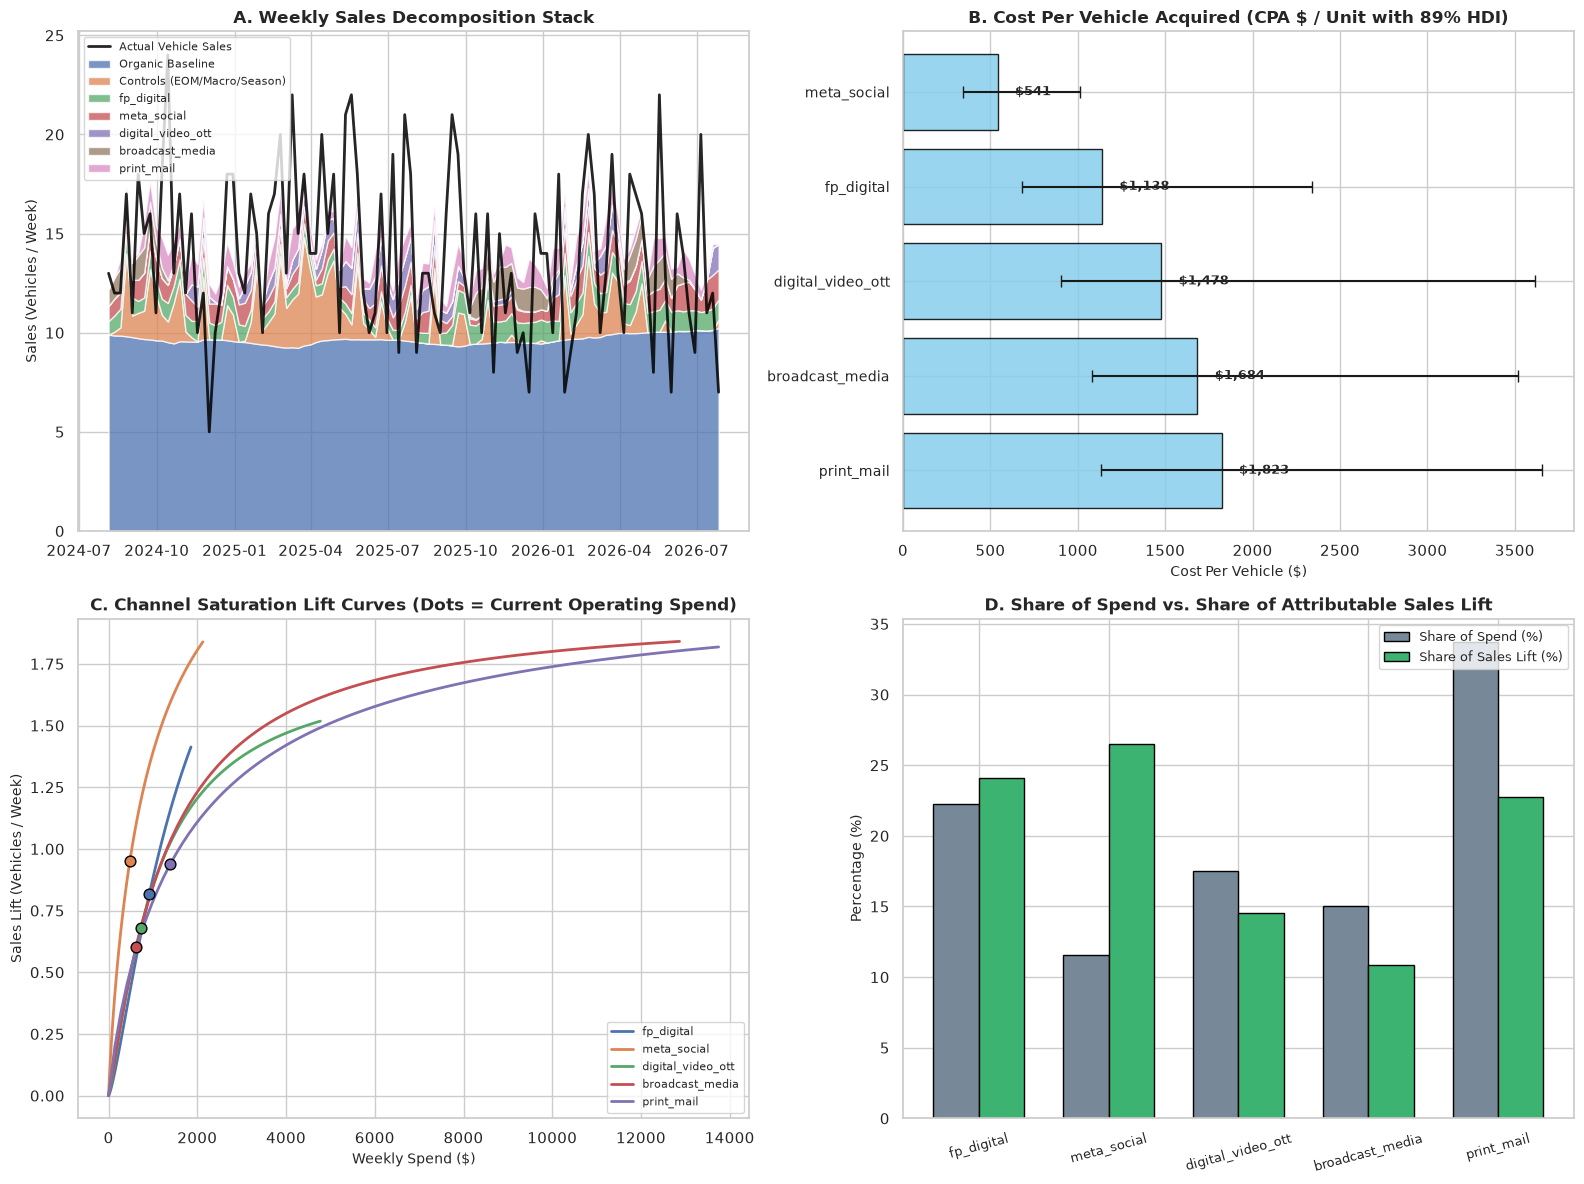

In [33]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

# ==============================================================================
# CELL 11: FULL DECOMPOSITION, CPA ANALYSIS, AND EXECUTIVE DASHBOARD
# ==============================================================================

# 1. Scope Constants & Global Variables
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']
n_obs = len(df_model)
sales_mean = df_model['sales'].mean()
actual_sales = df_model['sales'].values
dates = pd.to_datetime(df_model['week_start'])

# 2. Extract Posterior Tensors across Chains and Draws
post_draws = az.extract(idata, combined=True)
n_draws = post_draws.sizes['sample']

beta_draws = post_draws["beta_channel"].values * sales_mean  # Shape: (n_channels, n_draws)
k_sat_draws = post_draws["k_sat"].values if "k_sat" in post_draws else post_draws["k_val"].values
s_slope_draws = post_draws["s_slope"].values if "s_slope" in post_draws else np.ones((len(media_channels), n_draws))

intercept_draws = post_draws["intercept"].values * sales_mean
beta_inv_draws = post_draws["beta_inv"].values * sales_mean
beta_eom_draws = post_draws["beta_eom"].values * sales_mean
beta_macro_draws = post_draws["beta_macro"].values * sales_mean
beta_fourier_draws = post_draws["beta_fourier"].values * sales_mean # Shape: (4, n_draws)

# Extract Pre-Adstocked Media Tensor from PyMC Data Container
X_adstocked_data = idata.constant_data["adstocked_data"].values # Shape: (104, 5)

# 3. Compute Weekly Decomposition & Channel Lift Tensors
# Dimensions: (n_obs, n_channels, n_draws)
channel_lift_tensor = np.zeros((n_obs, len(media_channels), n_draws))

for m in range(len(media_channels)):
    x_adstocked_m = X_adstocked_data[:, m][:, None] # Shape: (104, 1)
    k_m = k_sat_draws[m, :][None, :]                # Shape: (1, n_draws)
    s_m = s_slope_draws[m, :][None, :]              # Shape: (1, n_draws)
    beta_m = beta_draws[m, :][None, :]              # Shape: (1, n_draws)
    
    x_s = np.power(x_adstocked_m, s_m)
    k_s = np.power(k_m, s_m)
    
    # Saturation Hill transformation
    channel_lift_tensor[:, m, :] = (x_s / (x_s + k_s + 1e-8)) * beta_m

# Sum weekly lift per channel across time horizon N=104
total_channel_lifts_draws = np.sum(channel_lift_tensor, axis=0) # Shape: (5, n_draws)
weekly_channel_lifts_mean = np.mean(channel_lift_tensor, axis=2) # Shape: (104, 5)

# Total Historical Spend per Channel
total_spends = np.array([df_model[c].sum() for c in media_channels])
weekly_avg_spends = np.array([df_model[c].mean() for c in media_channels])
total_marketing_spend = np.sum(total_spends)

# 4. Compute Acquisition Metrics (CPA & Share of Effect)
cpa_draws = total_spends[:, None] / (total_channel_lifts_draws + 1e-8) # $/Vehicle
total_lift_per_draw = np.sum(total_channel_lifts_draws, axis=0)
soe_draws = (total_channel_lifts_draws / total_lift_per_draw) * 100.0   # Share of Effect (%)

# Calculate 89% Credible Intervals (Version-Safe Percentiles)
cpa_medians = np.median(cpa_draws, axis=1)
cpa_l89 = np.percentile(cpa_draws, 5.5, axis=1)
cpa_u89 = np.percentile(cpa_draws, 94.5, axis=1)

lift_weekly_medians = np.median(total_channel_lifts_draws / n_obs, axis=1)
lift_weekly_l89 = np.percentile(total_channel_lifts_draws / n_obs, 5.5, axis=1)
lift_weekly_u89 = np.percentile(total_channel_lifts_draws / n_obs, 94.5, axis=1)

soe_medians = np.median(soe_draws, axis=1)
sos_shares = (total_spends / total_marketing_spend) * 100.0

# Build Executive Attribution Table
attribution_df = pd.DataFrame({
    "Channel": media_channels,
    "Avg Spend ($/Wk)": weekly_avg_spends,
    "Share of Spend (%)": sos_shares,
    "Weekly Lift Median (Veh)": lift_weekly_medians,
    "89% HDI Weekly Lift": [f"[{lift_weekly_l89[i]:.2f} - {lift_weekly_u89[i]:.2f}]" for i in range(len(media_channels))],
    "CPA Median ($/Veh)": cpa_medians,
    "89% HDI CPA ($)": [f"[${cpa_l89[i]:,.0f} - ${cpa_u89[i]:,.0f}]" for i in range(len(media_channels))],
    "Share of Lift (%)": soe_medians
}).sort_values("CPA Median ($/Veh)")

print("=" * 95)
print("DEALERSHIP COMMERCIAL ATTRIBUTION & ACQUISITION EFFICIENCY TABLE")
print("=" * 95)
print(attribution_df.to_string(index=False, formatters={
    "Avg Spend ($/Wk)": "${:,.2f}".format,
    "Share of Spend (%)": "{:.1f}%".format,
    "Weekly Lift Median (Veh)": "{:.2f} v/wk".format,
    "CPA Median ($/Veh)": "${:,.2f}".format,
    "Share of Lift (%)": "{:.1f}%".format
}))
print("-" * 95)

# 5. Generate 4-Panel Executive Visualization Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# --- PANEL 1: Weekly Sales Stacked Decomposition ---
baseline_series = np.mean(intercept_draws) + np.mean(beta_inv_draws) * df_model["inventory_index"].values
controls_series = (
    np.mean(beta_eom_draws) * df_model["eom_intensity"].values 
    + np.mean(beta_macro_draws) * df_model["macro_stress_index"].values
    + np.dot(df_model[fourier_cols].values, np.mean(beta_fourier_draws, axis=1))
)

axes[0, 0].plot(dates, actual_sales, color='black', label='Actual Vehicle Sales', linewidth=2, alpha=0.85)
axes[0, 0].stackplot(
    dates, 
    baseline_series, 
    np.maximum(0, controls_series), 
    weekly_channel_lifts_mean.T,
    labels=['Organic Baseline', 'Controls (EOM/Macro/Season)', *media_channels],
    alpha=0.75
)
axes[0, 0].set_title("A. Weekly Sales Decomposition Stack", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Sales (Vehicles / Week)", fontsize=10)
axes[0, 0].legend(loc='upper left', fontsize=8, frameon=True)

# --- PANEL 2: Cost Per Vehicle Acquired (CPA) with 89% HDI ---
channels_sorted = attribution_df["Channel"].values
cpa_sorted = attribution_df["CPA Median ($/Veh)"].values
y_pos = np.arange(len(channels_sorted))

# Calculate asymmetric error bars for CPA 89% HDI
cpa_err_low = cpa_sorted - [float(x.split('[')[1].split(' -')[0].replace('$', '').replace(',', '')) for x in attribution_df["89% HDI CPA ($)"].values]
cpa_err_high = [float(x.split('- $')[1].split(']')[0].replace(',', '')) for x in attribution_df["89% HDI CPA ($)"].values] - cpa_sorted

axes[0, 1].barh(y_pos, cpa_sorted, xerr=[cpa_err_low, cpa_err_high], color='skyblue', edgecolor='black', alpha=0.85, capsize=4)
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels(channels_sorted, fontsize=10)
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("B. Cost Per Vehicle Acquired (CPA $ / Unit with 89% HDI)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Cost Per Vehicle ($)", fontsize=10)

for i, v in enumerate(cpa_sorted):
    axes[0, 1].text(v + 100, i, f"${v:,.0f}", va='center', fontweight='bold', fontsize=9)

# --- PANEL 3: Saturated Reach Curves & Operating Points ---
k_means = np.mean(k_sat_draws, axis=1)
s_means = np.mean(s_slope_draws, axis=1)
beta_means = np.mean(beta_draws, axis=1)

for m, chan in enumerate(media_channels):
    max_sp = df_model[chan].max() * 1.25
    x_sp = np.linspace(0, max_sp, 100)
    c_m = df_model[chan].mean() if df_model[chan].mean() > 0 else 1.0
    
    x_sc = x_sp / c_m
    y_curve = (np.power(x_sc, s_means[m]) / (np.power(x_sc, s_means[m]) + np.power(k_means[m], s_means[m]) + 1e-8)) * beta_means[m]
    
    line = axes[1, 0].plot(x_sp, y_curve, label=f"{chan}", linewidth=2)[0]
    
    # Plot current weekly average spend operating point
    curr_sp = weekly_avg_spends[m]
    curr_sc = curr_sp / c_m
    curr_lift = (np.power(curr_sc, s_means[m]) / (np.power(curr_sc, s_means[m]) + np.power(k_means[m], s_means[m]) + 1e-8)) * beta_means[m]
    axes[1, 0].scatter(curr_sp, curr_lift, color=line.get_color(), s=60, edgecolors='black', zorder=5)

axes[1, 0].set_title("C. Channel Saturation Lift Curves (Dots = Current Operating Spend)", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Sales Lift (Vehicles / Week)", fontsize=10)
axes[1, 0].set_xlabel("Weekly Spend ($)", fontsize=10)
axes[1, 0].legend(loc='lower right', fontsize=8, frameon=True)

# --- PANEL 4: Share of Spend vs. Share of Attributable Sales Lift ---
x_bar = np.arange(len(media_channels))
width = 0.35

axes[1, 1].bar(x_bar - width/2, sos_shares, width, label='Share of Spend (%)', color='lightslategrey', edgecolor='black')
axes[1, 1].bar(x_bar + width/2, soe_medians, width, label='Share of Sales Lift (%)', color='mediumseagreen', edgecolor='black')

axes[1, 1].set_xticks(x_bar)
axes[1, 1].set_xticklabels(media_channels, rotation=15, fontsize=9)
axes[1, 1].set_title("D. Share of Spend vs. Share of Attributable Sales Lift", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Percentage (%)", fontsize=10)
axes[1, 1].legend(loc='upper right', fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

🚀 Computing Point-Wise Log-Likelihood for TVP Model...


Sampling: [likelihood]


🚀 Generating Posterior Predictive Samples for TVP Model...


✅ Log-likelihood & Posterior Predictive attached successfully to idata_tvp!

STATISTICAL MODEL COMPARISON: STATIC vs. TIME-VARYING PARAMETER (TVP)
            Model Architecture R-Squared (R²) MAPE (%) RMSE (Vehicles)    ELPD LOO Score Pareto k Max
          Static Model (idata)         0.1398   23.68%       3.77 v/wk -18.38 (SE: 8.01)         0.28
Time-Varying Model (idata_tvp)         0.1654   23.77%       3.72 v/wk -24.54 (SE: 7.25)         0.43
-----------------------------------------------------------------------------------------------


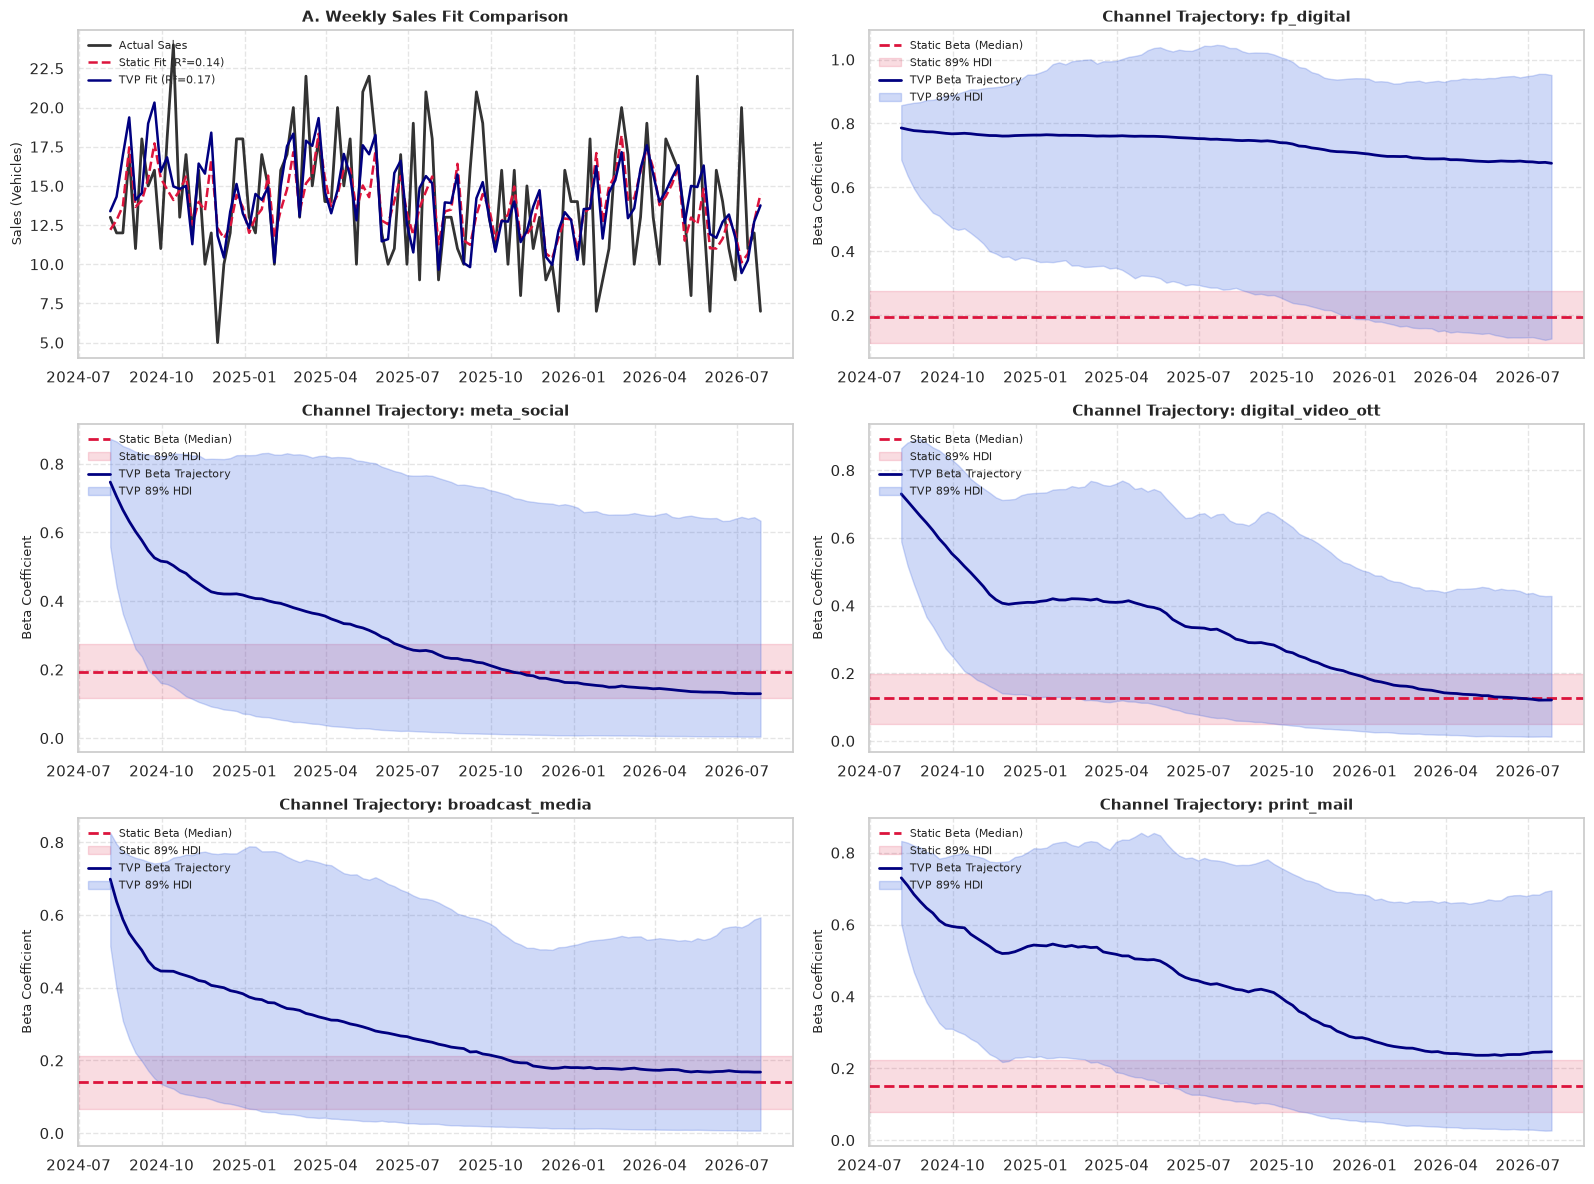

In [34]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr

# ==============================================================================
# STEP 1: COMPUTE LOG-LIKELIHOOD & POSTERIOR PREDICTIVE FOR idata_tvp
# ==============================================================================

with tvp_model:
  print("🚀 Computing Point-Wise Log-Likelihood for TVP Model...")
  pm.compute_log_likelihood(idata_tvp)

  print("🚀 Generating Posterior Predictive Samples for TVP Model...")
  pm.sample_posterior_predictive(
      idata_tvp, extend_inferencedata=True, random_seed=42
  )

print(
    "✅ Log-likelihood & Posterior Predictive attached successfully to"
    " idata_tvp!\n"
)

# ==============================================================================
# STEP 2: SIDE-BY-SIDE STATISTICAL ANALYSIS (idata vs idata_tvp)
# ==============================================================================

media_channels = [
    "fp_digital",
    "meta_social",
    "digital_video_ott",
    "broadcast_media",
    "print_mail",
]
sales_mean = df_model["sales"].mean()
actual_sales = df_model["sales"].values
dates = pd.to_datetime(df_model["week_start"])
n_obs = len(df_model)


def extract_ppc_median(idata_obj):
  """Safely extracts median unscaled posterior predictive sales array across DataTree/DataArray/Dataset types."""
  ppc = az.extract(idata_obj, group="posterior_predictive")

  if isinstance(ppc, xr.DataArray):
    vals = ppc.values
  elif isinstance(ppc, xr.Dataset):
    key = (
        "likelihood"
        if "likelihood" in ppc.data_vars
        else list(ppc.data_vars)[0]
    )
    vals = ppc[key].values
  else:
    vals = np.asarray(ppc)

  if vals.shape[0] == n_obs:
    return np.median(vals * sales_mean, axis=1)
  else:
    return np.median(vals.T * sales_mean, axis=1)


# Extract Predictions
pred_static_med = extract_ppc_median(idata)
pred_tvp_med = extract_ppc_median(idata_tvp)


# Compute Accuracy & LOO Metrics
def compute_metrics(actual, pred):
  mape = np.mean(np.abs((actual - pred) / actual)) * 100
  rmse = np.sqrt(np.mean((actual - pred) ** 2))
  r2 = float(
      1.0
      - (
          np.sum((actual - pred) ** 2)
          / np.sum((actual - np.mean(actual)) ** 2)
      )
  )
  return mape, rmse, r2


mape_s, rmse_s, r2_s = compute_metrics(actual_sales, pred_static_med)
mape_t, rmse_t, r2_t = compute_metrics(actual_sales, pred_tvp_med)

loo_static = az.loo(idata)
loo_tvp = az.loo(idata_tvp)


def get_loo_elpd(loo_obj):
  if hasattr(loo_obj, "elpd_loo"):
    return float(loo_obj.elpd_loo)
  elif hasattr(loo_obj, "elpd"):
    return float(loo_obj.elpd)
  else:
    return float(loo_obj["elpd"])


def get_loo_se(loo_obj):
  if hasattr(loo_obj, "se"):
    return float(loo_obj.se)
  elif hasattr(loo_obj, "se_elpd_loo"):
    return float(loo_obj.se_elpd_loo)
  else:
    return float(loo_obj["se"])


def get_max_pareto_k(loo_obj):
  k = (
      loo_obj.pareto_k.values
      if hasattr(loo_obj, "pareto_k")
      else loo_obj.khat.values
  )
  return float(np.max(k))


elpd_s, se_s = get_loo_elpd(loo_static), get_loo_se(loo_static)
elpd_t, se_t = get_loo_elpd(loo_tvp), get_loo_se(loo_tvp)

# Summary Comparison Table
comparison_df = pd.DataFrame({
    "Model Architecture": [
        "Static Model (idata)",
        "Time-Varying Model (idata_tvp)",
    ],
    "R-Squared (R²)": [f"{r2_s:.4f}", f"{r2_t:.4f}"],
    "MAPE (%)": [f"{mape_s:.2f}%", f"{mape_t:.2f}%"],
    "RMSE (Vehicles)": [f"{rmse_s:.2f} v/wk", f"{rmse_t:.2f} v/wk"],
    "ELPD LOO Score": [
        f"{elpd_s:.2f} (SE: {se_s:.2f})",
        f"{elpd_t:.2f} (SE: {se_t:.2f})",
    ],
    "Pareto k Max": [
        f"{get_max_pareto_k(loo_static):.2f}",
        f"{get_max_pareto_k(loo_tvp):.2f}",
    ],
})

print("=" * 95)
print("STATISTICAL MODEL COMPARISON: STATIC vs. TIME-VARYING PARAMETER (TVP)")
print("=" * 95)
print(comparison_df.to_string(index=False))
print("-" * 95)

# Render Trajectory Dashboard
post_static = az.extract(idata)
post_tvp = az.extract(idata_tvp)

beta_static_draws = post_static["beta_channel"].values
beta_tvp_raw = post_tvp["beta_channel_t"].values

if beta_tvp_raw.shape[0] != n_obs:
  beta_tvp_raw = np.swapaxes(beta_tvp_raw, 0, 1)


def get_hdi_bounds(arr, axis=-1):
  low = np.percentile(arr, 5.5, axis=axis)
  high = np.percentile(arr, 94.5, axis=axis)
  med = np.median(arr, axis=axis)
  return med, low, high


fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# Subplot 0: Sales Fit
axes[0].plot(
    dates,
    actual_sales,
    color="black",
    label="Actual Sales",
    linewidth=2,
    alpha=0.8,
)
axes[0].plot(
    dates,
    pred_static_med,
    color="crimson",
    linestyle="--",
    label=f"Static Fit (R²={r2_s:.2f})",
    linewidth=1.8,
)
axes[0].plot(
    dates,
    pred_tvp_med,
    color="navy",
    linestyle="-",
    label=f"TVP Fit (R²={r2_t:.2f})",
    linewidth=1.8,
)
axes[0].set_title(
    "A. Weekly Sales Fit Comparison", fontsize=11, fontweight="bold"
)
axes[0].set_ylabel("Sales (Vehicles)", fontsize=9)
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Subplots 1-5: Channel Trajectories
for i, chan in enumerate(media_channels):
  ax = axes[i + 1]

  s_med, s_low, s_high = get_hdi_bounds(beta_static_draws[i, :])
  ax.axhline(
      s_med,
      color="crimson",
      linestyle="--",
      label="Static Beta (Median)",
      linewidth=2,
  )
  ax.axhspan(
      s_low, s_high, color="crimson", alpha=0.15, label="Static 89% HDI"
  )

  t_draws = beta_tvp_raw[:, i, :]
  t_med, t_low, t_high = get_hdi_bounds(t_draws, axis=1)

  ax.plot(
      dates, t_med, color="navy", label="TVP Beta Trajectory", linewidth=2
  )
  ax.fill_between(
      dates,
      t_low,
      t_high,
      color="royalblue",
      alpha=0.25,
      label="TVP 89% HDI",
  )

  ax.set_title(
      f"Channel Trajectory: {chan}", fontsize=11, fontweight="bold"
  )
  ax.set_ylabel("Beta Coefficient", fontsize=9)
  ax.legend(loc="upper left", fontsize=8)
  ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()